In [1]:
import pandas as pd

In [2]:
df =  pd.read_csv("data/main/dataset.csv")

In [3]:
df.shape

(411, 83)

In [4]:
df 

,Unnamed: 0,repo_name,num_contributors,total_contributions,top1_contribution_share,top5_contribution_share,contribution_gini,median_contributions,num_deployments,has_deployments,...,contributors_to_stars_ratio,tag_release_velocity,interaction_ratio,development_ratio,external_interest_event_ratio,stars_per_size,forks_per_size,issues_per_size,error,label
0,0,feast-dev/feast,30.0,3139.0,0.173941,0.475948,0.475385,61.5,30.0,1.0,...,0.004283,0.011096,0.100000,0.466667,0.266667,0.027528,0.005168,0.001360,NaN,1
1,1,tmux/tmux,19.0,9800.0,0.802143,0.997551,0.923963,2.0,0.0,0.0,...,0.000421,0.007521,0.500000,0.066667,0.366667,2.358165,0.135984,0.002873,NaN,1
2,2,ultralytics/ultralytics,30.0,3551.0,0.443537,0.813292,0.779283,21.5,30.0,1.0,...,0.000525,0.022346,0.333333,0.366667,0.233333,1.037995,0.199797,0.005900,NaN,1
3,3,denoland/fresh,30.0,1396.0,0.474928,0.803009,0.767240,8.5,30.0,1.0,...,0.002181,0.016352,0.333333,0.366667,0.133333,0.300949,0.016385,0.001794,NaN,1
4,4,milvus-io/milvus,30.0,17783.0,0.096947,0.307372,0.252978,506.5,0.0,0.0,...,0.000677,0.012326,0.500000,0.466667,0.033333,0.151276,0.013655,0.003018,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,406,Solido/awesome-flutter,30.0,473.0,0.689218,0.773784,0.715927,4.0,30.0,1.0,...,0.000500,0.000000,0.000000,0.033333,0.966667,16.931151,1.939334,0.006772,NaN,0
407,407,fabricjs/fabric.js,30.0,4830.0,0.414079,0.908075,0.842636,18.5,30.0,1.0,...,0.000963,0.005155,0.233333,0.033333,0.733333,0.125760,0.014633,0.001893,NaN,0
408,408,octocat/Hello-World,3.0,3.0,0.333333,1.000000,0.000000,1.0,0.0,0.0,...,0.000839,0.000000,0.166667,0.000000,0.800000,3575.000000,6157.000000,5863.000000,NaN,0
409,409,docker/getting-started,30.0,166.0,0.421687,0.819277,0.744980,1.0,0.0,0.0,...,0.009794,0.000000,0.142857,0.000000,0.821429,0.571669,1.191863,0.020903,NaN,0


In [5]:
df.drop(columns=["Unnamed: 0", "repo_name"], inplace=True)

In [6]:
df["label"].value_counts()

label
1    274
0    137
Name: count, dtype: int64

In [7]:
df.columns

Index(['num_contributors', 'total_contributions', 'top1_contribution_share',
       'top5_contribution_share', 'contribution_gini', 'median_contributions',
       'num_deployments', 'has_deployments', 'num_unique_refs',
       'tag_based_deployment_ratio', 'deployment_recency_days', 'num_events',
       'num_unique_event_types', 'dominant_event_type', 'dominant_event_ratio',
       'event_type_entropy', 'has_IssuesEvent', 'has_PullRequestEvent',
       'has_IssueCommentEvent', 'recent_event_density', 'IssuesEvent_ratio',
       'IssueCommentEvent_ratio', 'PullRequestEvent_ratio', 'PushEvent_ratio',
       'WatchEvent_ratio', 'ForkEvent_ratio', 'stargazers_count',
       'subscribers_count', 'subscribers_to_stars_ratio',
       'primary_language_ratio', 'top2_ratio', 'top3_ratio',
       'language_entropy', 'minor_lang_ratio', 'infra_ratio', 'markup_ratio',
       'is_monolingual', 'compiled_ratio', 'num_tags', 'stable_tag_ratio',
       'prerelease_tag_ratio', 'latest_tag_is_stable',
 


---

# OSS Health Score 기반 Target Labeling 절차

## 1. Target Labeling 문제 정의

본 프로젝트의 목표는 GitHub Open Source Repository가 운영적으로 건강한 상태인지 판단하는 것이다.
그러나 OSS Health는 명확한 정답 label이 존재하지 않는 개념이다. 따라서 단순히 사람이 주관적으로 repository를 healthy/unhealthy로 분류하는 방식은 기준의 일관성이 떨어질 수 있다.

이에 본 프로젝트에서는 OSS Health를 여러 평가 차원으로 분해한 뒤, 각 차원을 GitHub에서 관측 가능한 feature로 변환하고, 이를 종합한 Health Score를 기준으로 target label을 생성하였다.

---

# 2. OSS Health의 다차원 정의

OSS Health는 단일 지표가 아니라 다음과 같은 여러 차원의 운영 성숙도로 정의하였다.

| 평가 차원    | 세부 개념                 | 의미                                             |
| -------- | --------------------- | ---------------------------------------------- |
| 커뮤니티 활성도 | Activity Volume       | 프로젝트 내 전반적인 활동량                                |
| 커뮤니티 활성도 | Engagement Quality    | issue, PR, comment 등을 통한 상호작용 수준               |
| 지속 가능성   | Contributor Structure | 특정 contributor에 대한 의존도                         |
| 지속 가능성   | Activity Stability    | 최근까지 유지보수가 지속되는 정도                             |
| 프로젝트 성숙도 | Release Engineering   | tag, deployment, semantic versioning 기반 릴리즈 체계 |
| 프로젝트 성숙도 | Adoption / Popularity | star, fork, subscriber 기반 외부 수용도               |
| 기술적 구조   | Language Structure    | 언어 구성의 집중도 및 복잡도                               |
| 운영 거버넌스  | Governance Structure  | issue, wiki, discussion, PR 기능 등 운영 기능 활용 여부   |
| 유지보수성    | Maintenance           | update, push, repository age 기반 유지보수 상태        |

---

# 3. Feature 기반 Operationalization

각 health dimension은 GitHub API 및 repository metadata에서 수집 가능한 feature로 변환하였다.

예를 들어 contributor structure는 `contribution_gini`, `top1_contribution_share`, `contribution_entropy`로 측정하고, release engineering은 `num_tags`, `semver_tag_ratio`, `stable_tag_ratio`, `num_deployments` 등으로 측정하였다.

즉, 추상적인 OSS Health 개념을 실제 데이터 기반의 measurable signal로 변환하였다.

---

# 4. Equal-weighted Health Score 계산

특정 평가 차원에 더 큰 가중치를 부여하면 연구자의 주관적 판단이 개입될 수 있다.
따라서 본 프로젝트에서는 모든 health dimension에 동일한 가중치를 부여하였다.

절차는 다음과 같다.

1. 각 feature의 방향성을 정의한다.

   * 값이 클수록 healthy한 feature
   * 값이 작을수록 healthy한 feature
   * binary 상태 feature

2. feature별 값을 0~1 범위로 정규화한다.

3. 각 health dimension별 평균 score를 계산한다.

4. 모든 dimension score를 동일 가중치로 평균하여 최종 `oss_health_score`를 계산한다.

---

# 5. Score 기반 Pseudo-label 생성

최종적으로 계산된 `oss_health_score`의 분포를 기준으로 label을 생성하였다.

| 기준    | Label          |
| ----- | -------------- |
| 상위 구간 | 1, Healthy     |
| 하위 구간 | 0, Unhealthy   |
| 중간 구간 | 불확실 영역으로 제외 가능 |

중간 구간을 제외하는 이유는 health 상태가 애매한 repository까지 강제로 labeling하면 label noise가 커질 수 있기 때문이다.

따라서 본 프로젝트에서는 Health Score 상위 repository를 healthy seed, 하위 repository를 unhealthy seed로 정의하고, 이를 기반으로 binary classification model을 학습한다.

---

# 6. 최종 분석 구조

본 프로젝트의 전체 구조는 다음과 같다.

```text
GitHub Repository Data
        ↓
Health Dimension 정의
        ↓
Feature Mapping
        ↓
Equal-weighted OSS Health Score 계산
        ↓
Score 기반 pseudo-label 생성
        ↓
Healthy / Unhealthy Binary Classification
        ↓
Sector-wise Health Score 및 주요 Feature 해석
```

---


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


# 데이터 복사
df_labeled = df.copy()


# 제거할 컬럼 정의
drop_cols = [
    "dominant_event_type",
    "error",
    "label"
]

existing_drop_cols = [
    col for col in drop_cols
    if col in df_labeled.columns
]


# Health dimension별 feature 정의
health_dimensions = {
    "community_activity": [
        "num_events",
        "num_unique_event_types",
        "event_type_entropy",
        "recent_event_density",
        "has_IssuesEvent",
        "has_PullRequestEvent",
        "has_IssueCommentEvent",
        "IssuesEvent_ratio",
        "IssueCommentEvent_ratio",
        "PullRequestEvent_ratio",
        "PushEvent_ratio",
        "interaction_ratio",
        "development_ratio",
    ],

    "contributor_sustainability": [
        "num_contributors",
        "total_contributions",
        "median_contributions",
        "contribution_entropy",
        "top1_contribution_share",
        "top5_contribution_share",
        "contribution_gini",
        "top1_contribution_ratio",
        "top3_contribution_ratio",
        "contributors_to_stars_ratio",
    ],

    "release_engineering": [
        "num_deployments",
        "has_deployments",
        "num_unique_refs",
        "tag_based_deployment_ratio",
        "num_tags",
        "stable_tag_ratio",
        "latest_tag_is_stable",
        "semver_tag_ratio",
        "num_major_versions",
        "num_minor_versions",
        "tag_release_velocity",
        "deployment_recency_days",
        "prerelease_tag_ratio",
        "latest_tag_is_prerelease",
    ],

    "popularity_adoption": [
        "stargazers_count",
        "subscribers_count",
        "forks_count",
        "network_count",
        "subscribers_to_stars_ratio",
        "forks_to_stars_ratio",
        "stars_per_repo_age_day",
        "forks_per_repo_age_day",
        "stars_per_size",
        "forks_per_size",
        "external_interest_event_ratio",
    ],

    "language_structure": [
        "primary_language_ratio",
        "top2_ratio",
        "top3_ratio",
        "language_entropy",
        "minor_lang_ratio",
        "infra_ratio",
        "markup_ratio",
        "is_monolingual",
        "compiled_ratio",
    ],

    "maintenance": [
        "repo_age_days",
        "last_update_recency_days",
        "last_push_recency_days",
        "update_push_gap_days",
    ],

    "governance": [
        "repo_size",
        "open_issues_count",
        "has_issues",
        "has_projects",
        "has_downloads",
        "has_wiki",
        "has_pages",
        "has_discussions",
        "archived",
        "disabled",
        "allow_forking",
        "has_pull_requests",
        "open_issues_to_stars_ratio",
        "issues_per_size",
    ],
}


# 값이 작을수록 healthy한 feature 정의
negative_features = [
    "top1_contribution_share",
    "top5_contribution_share",
    "contribution_gini",
    "top1_contribution_ratio",
    "top3_contribution_ratio",
    "deployment_recency_days",
    "prerelease_tag_ratio",
    "latest_tag_is_prerelease",
    "last_update_recency_days",
    "last_push_recency_days",
    "update_push_gap_days",
    "open_issues_to_stars_ratio",
    "issues_per_size",
    "dominant_event_ratio",
    "archived",
    "disabled",
]


# 실제 존재하는 feature만 사용
for dim, features in health_dimensions.items():
    health_dimensions[dim] = [
        col for col in features
        if col in df_labeled.columns
    ]


# 전체 feature 목록 생성
all_features = sorted(set(sum(health_dimensions.values(), [])))


# 수치형 변환
for col in all_features:
    df_labeled[col] = pd.to_numeric(
        df_labeled[col],
        errors="coerce"
    )


# 결측치 median 대체
for col in all_features:
    median_value = df_labeled[col].median()
    df_labeled[col] = df_labeled[col].fillna(median_value)


# Feature별 0~1 정규화
scaled_df = pd.DataFrame(index=df_labeled.index)

for col in all_features:
    values = df_labeled[[col]].copy()

    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(values)

    scaled_df[col] = scaled_values.flatten()

    if col in negative_features:
        scaled_df[col] = 1 - scaled_df[col]


# Dimension별 score 계산
for dim, features in health_dimensions.items():

    if len(features) > 0:
        df_labeled[f"{dim}_score"] = (
            scaled_df[features]
            .mean(axis=1)
        )

    else:
        df_labeled[f"{dim}_score"] = np.nan


# 최종 OSS Health Score 계산
dimension_score_cols = [
    f"{dim}_score"
    for dim in health_dimensions.keys()
    if f"{dim}_score" in df_labeled.columns
]

df_labeled["oss_health_score"] = (
    df_labeled[dimension_score_cols]
    .mean(axis=1)
)


# Score 기반 label 재부여
upper_q = df_labeled["oss_health_score"].quantile(0.70)
lower_q = df_labeled["oss_health_score"].quantile(0.30)

threshold = df_labeled["oss_health_score"].median()

df_labeled["new_label"] = (
    df_labeled["oss_health_score"] >= threshold
).astype(int)

df_train = df_labeled.copy()

# 결과 확인
print("Original shape:", df.shape)
print("Relabeled shape:", df_labeled.shape)
print("Train shape:", df_train.shape)

print("\nNew label distribution:")
print(df_train["new_label"].value_counts(normalize=True))
print(df_train["new_label"].value_counts())

print("\nOSS Health Score summary:")
print(df_labeled["oss_health_score"].describe())

print("\nDimension score columns:")
print(dimension_score_cols)

Original shape: (411, 81)
Relabeled shape: (411, 90)
Train shape: (411, 90)

New label distribution:
new_label
1    0.501217
0    0.498783
Name: proportion, dtype: float64
new_label
1    206
0    205
Name: count, dtype: int64

OSS Health Score summary:
count    411.000000
mean       0.459395
std        0.065807
min        0.241144
25%        0.421448
50%        0.473827
75%        0.509230
max        0.597762
Name: oss_health_score, dtype: float64

Dimension score columns:
['community_activity_score', 'contributor_sustainability_score', 'release_engineering_score', 'popularity_adoption_score', 'language_structure_score', 'maintenance_score', 'governance_score']


In [9]:
pd.crosstab(df_train["label"], df_train["new_label"])

new_label,0,1
label,,
0,111,26
1,94,180


In [10]:
df_labeled.to_csv("oss_health_score_labeled_full.csv", index=False)
df_train.to_csv("oss_health_score_labeled_train.csv", index=False)

In [11]:
target_col = "new_label"

exclude_cols = [
    "label",
    "new_label",
    "oss_health_score",
    "dominant_event_type",
    "error",
] + dimension_score_cols


feature_cols = [
    col for col in df_train.columns
    if col not in exclude_cols
]


X = df_train[feature_cols].select_dtypes(
    include=[np.number]
)

y = df_train[target_col]


print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNon-numeric columns removed automatically.")

X shape: (411, 78)
y shape: (411,)

Non-numeric columns removed automatically.


### Simple Model Test

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier


# 1. train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))


# 2. 모델 정의

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
}


# 3. 결과 저장용

results = []


# 4. 모델 학습 및 평가

for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # 결측치 처리 + 모델
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

    # 학습
    pipeline.fit(X_train, y_train)

    # 예측
    y_pred = pipeline.predict(X_test)

    # 확률값
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    # metric 계산
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    # 저장
    results.append({
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    })

    # 출력
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nMetrics")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")


# 5. 결과 테이블

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(results_df.sort_values("roc_auc", ascending=False))


# 6. 최고 성능 모델 확인

best_model_row = results_df.sort_values(
    "roc_auc",
    ascending=False
).iloc[0]

print("\nBest Model")
print(best_model_row)

X_train: (328, 78)
X_test : (83, 78)
y_train distribution:
new_label
0    0.5
1    0.5
Name: proportion, dtype: float64

LogisticRegression


/Users/carolyn/Desktop/3-1/opensource/data/oss-health-data/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        41
           1       0.82      0.86      0.84        42

    accuracy                           0.83        83
   macro avg       0.83      0.83      0.83        83
weighted avg       0.83      0.83      0.83        83


Confusion Matrix
[[33  8]
 [ 6 36]]

Metrics
Accuracy : 0.8313
Precision: 0.8182
Recall   : 0.8571
F1 Score : 0.8372
ROC-AUC  : 0.9019

RandomForest

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        41
           1       0.95      0.90      0.93        42

    accuracy                           0.93        83
   macro avg       0.93      0.93      0.93        83
weighted avg       0.93      0.93      0.93        83


Confusion Matrix
[[39  2]
 [ 4 38]]

Metrics
Accuracy : 0.9277
Precision: 0.9500
Recall   : 0.9048
F1 Score : 0.9268
ROC-AUC  : 0.9576

ExtraTrees

C

---

# **Feature Engineering**

> ## 1st Analysis

## **1. contributor_features**

**의미**

“누가 얼마나 다양하게 유지보수하는가”

**핵심 질문**

- 소수 maintainer 의존도가 높은가?
- contributor 생태계가 건강한가?
- bus factor 위험이 있는가?

In [13]:
contributor_features = [
    "num_contributors",
    "total_contributions",
    "top1_contribution_share",
    "top5_contribution_share",
    "contribution_gini",
    "median_contributions",
    "top1_contribution_ratio",
    "top3_contribution_ratio",
    "contribution_entropy",
    "contributors_to_stars_ratio",
]

| 컬럼명                           | 의미                                      | 해석                                     |
| ----------------------------- | --------------------------------------- | -------------------------------------- |
| `num_contributors`            | 프로젝트에 기여한 contributor 수                 | 유지보수 인력 규모와 커뮤니티 참여 정도를 나타냄            |
| `total_contributions`         | 전체 contribution 수 합계                    | 프로젝트 전체 개발 활동량을 의미                     |
| `top1_contribution_share`     | 가장 많이 기여한 1명의 contribution 비율           | 특정 maintainer 의존도가 높은지 확인 가능           |
| `top5_contribution_share`     | 상위 5명의 contribution 비율 합                | 핵심 contributor 그룹 집중도를 의미              |
| `contribution_gini`           | contribution 분포의 불균형 정도 (Gini 계수)       | 높을수록 소수 contributor 중심 구조              |
| `median_contributions`        | contributor별 contribution 중앙값           | 일반 contributor들의 평균적 참여 수준을 반영         |
| `top1_contribution_ratio`     | 상위 1명 contribution / 전체 contribution 비율 | maintainer 집중 구조 여부를 나타냄               |
| `top3_contribution_ratio`     | 상위 3명 contribution / 전체 contribution 비율 | 핵심 개발자 그룹 의존도를 의미                      |
| `contribution_entropy`        | contribution 분포의 다양성(entropy)           | 높을수록 contribution이 여러 contributor에 분산됨 |
| `contributors_to_stars_ratio` | contributor 수 대비 star 수 비율              | popularity 대비 실제 유지보수 참여 밀도를 의미        |


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

contributor_df = df[contributor_features + ["label"]].copy()

for col in contributor_features:
    contributor_df[col] = pd.to_numeric(contributor_df[col], errors="coerce")

summary_mean = contributor_df.groupby("label")[contributor_features].mean().T
summary_median = contributor_df.groupby("label")[contributor_features].median().T

summary = pd.concat(
    [
        summary_mean.rename(columns={0: "unhealthy_mean", 1: "healthy_mean"}),
        summary_median.rename(columns={0: "unhealthy_median", 1: "healthy_median"}),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"] - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"] - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_contributors,27.715328,29.540441,30.000000,30.000000,1.825113,0.000000
total_contributions,3546.299270,13445.981618,1666.000000,6053.000000,9899.682348,4387.000000
top1_contribution_share,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top5_contribution_share,0.787410,0.702931,0.819277,0.738417,-0.084480,-0.080860
contribution_gini,0.713175,0.659995,0.751116,0.707673,-0.053180,-0.043443
median_contributions,37.105839,209.253676,7.500000,40.000000,172.147837,32.500000
top1_contribution_ratio,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top3_contribution_ratio,0.703278,0.602344,0.711316,0.608311,-0.100934,-0.103005
contribution_entropy,1.878744,2.228391,2.008609,2.329305,0.349647,0.320696
contributors_to_stars_ratio,0.012369,0.001857,0.001853,0.000878,-0.010513,-0.000975


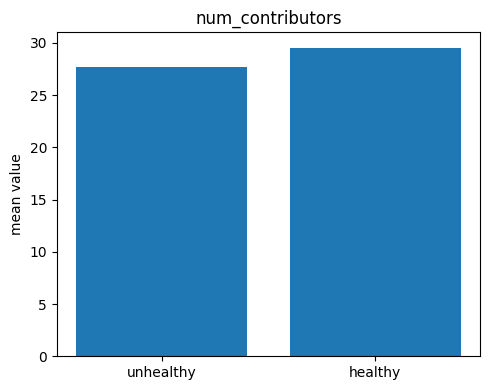

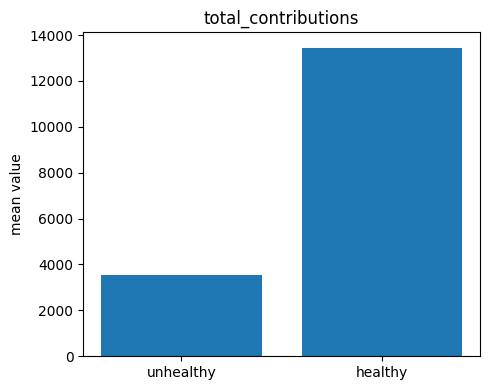

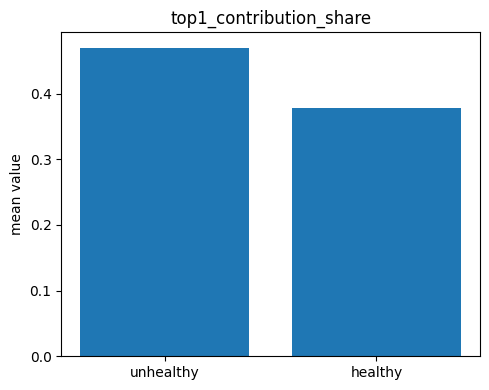

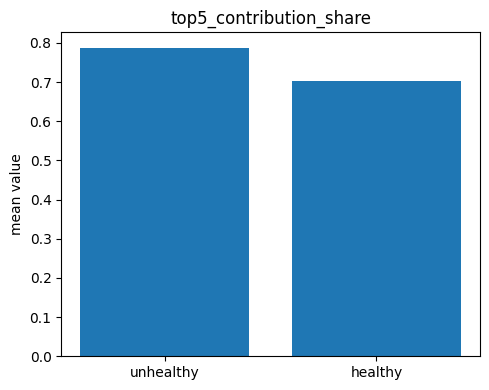

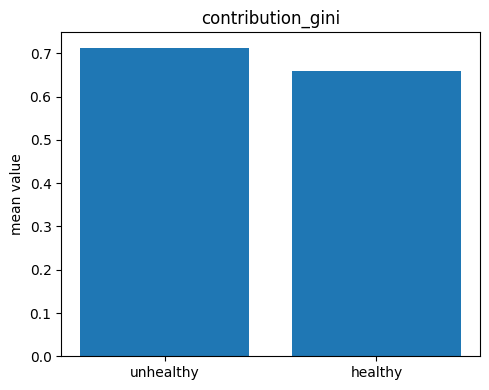

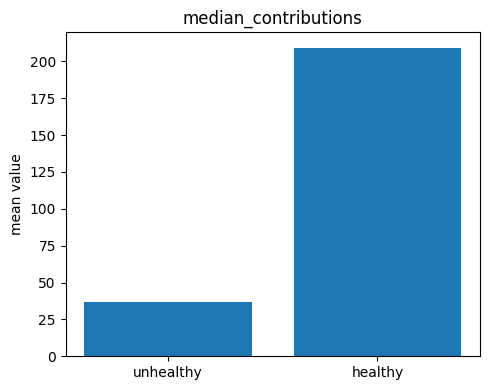

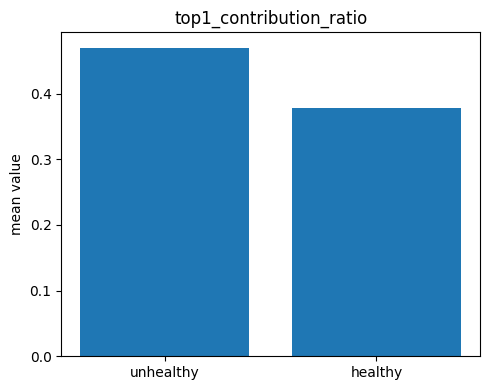

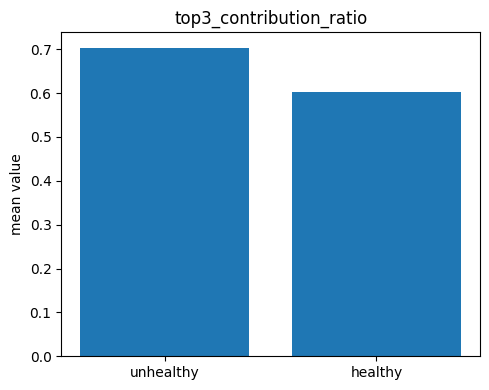

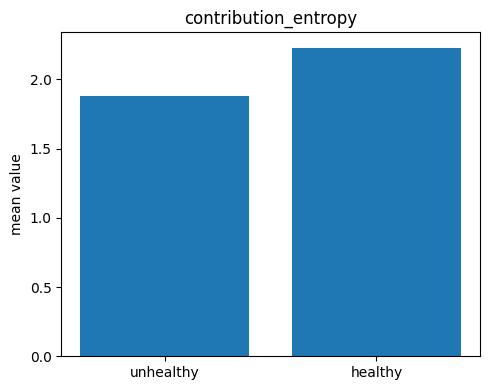

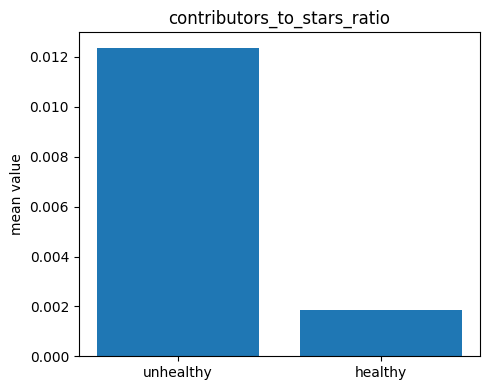

In [15]:
plot_df = summary[["unhealthy_mean", "healthy_mean"]].copy()

for feature in plot_df.index:
    plt.figure(figsize=(5, 4))
    values = plot_df.loc[feature]
    plt.bar(["unhealthy", "healthy"], values)
    plt.title(feature)
    plt.ylabel("mean value")
    plt.tight_layout()
    plt.show()

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


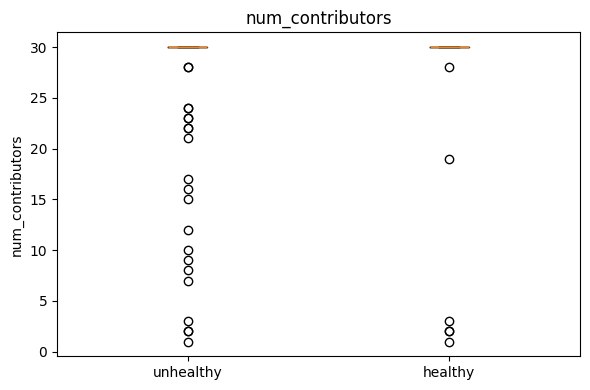

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


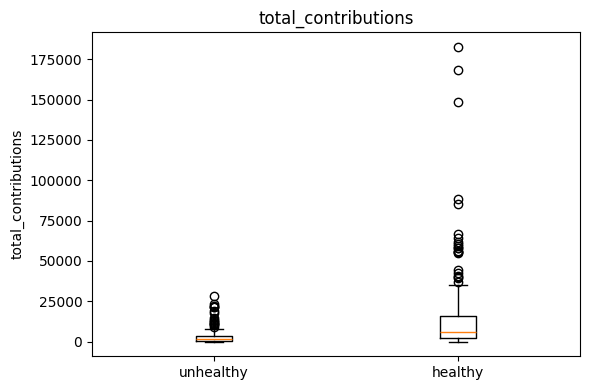

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


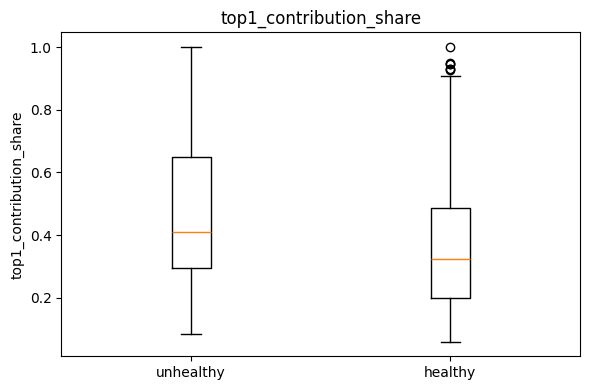

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


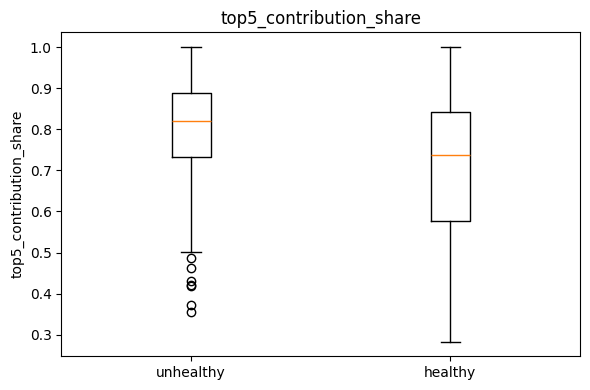

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


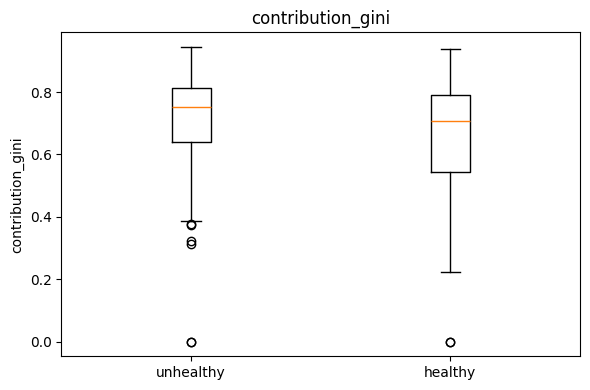

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


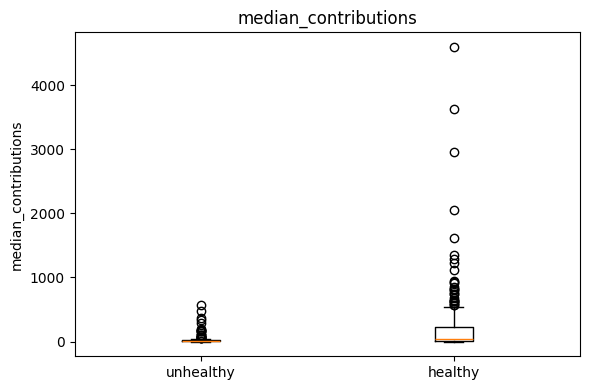

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


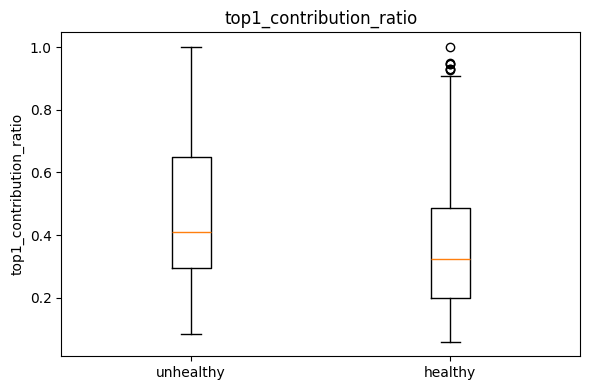

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


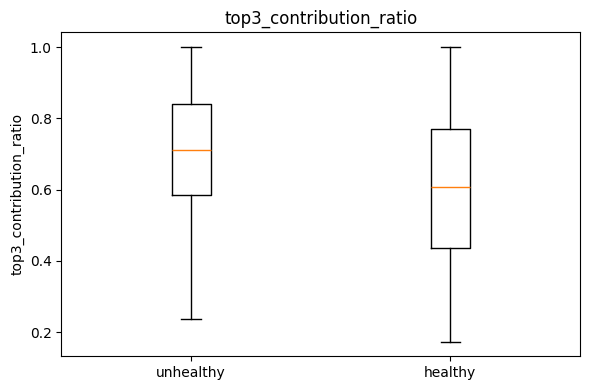

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


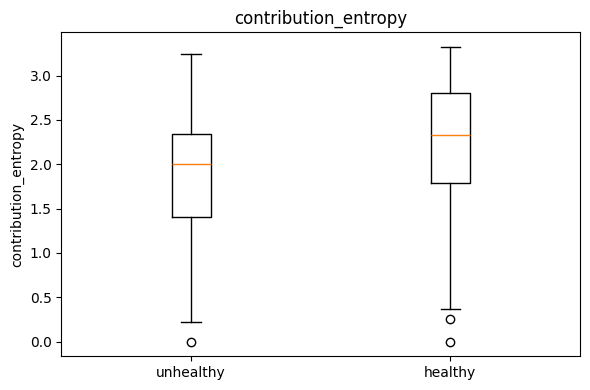

/var/folders/g8/gwqmqng10_g3h7m8r02yq1qc0000gn/T/ipykernel_42561/2533254159.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


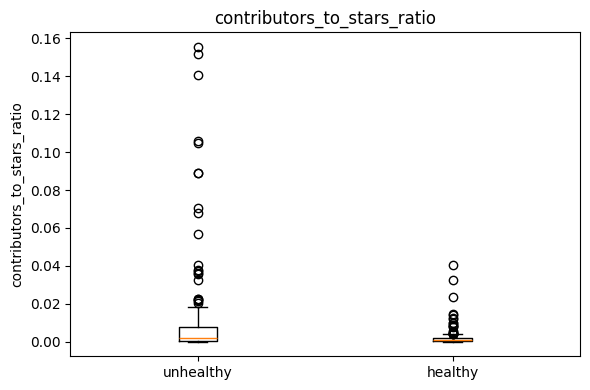

In [16]:
for feature in contributor_features:
    plt.figure(figsize=(6, 4))

    unhealthy_values = contributor_df.loc[
        contributor_df["label"] == 0, feature
    ].dropna()

    healthy_values = contributor_df.loc[
        contributor_df["label"] == 1, feature
    ].dropna()

    plt.boxplot(
        [unhealthy_values, healthy_values],
        labels=["unhealthy", "healthy"]
    )

    plt.title(feature)
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

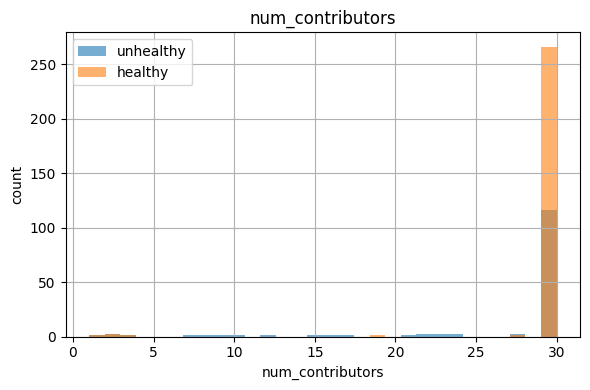

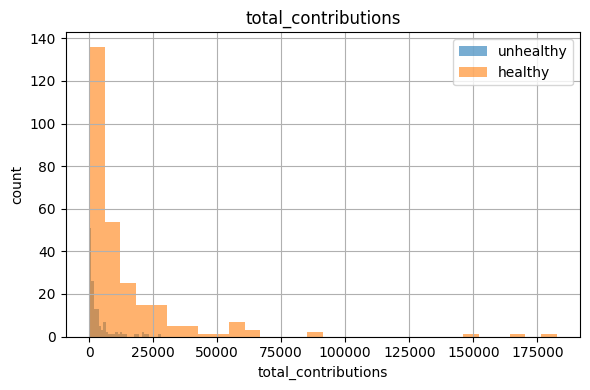

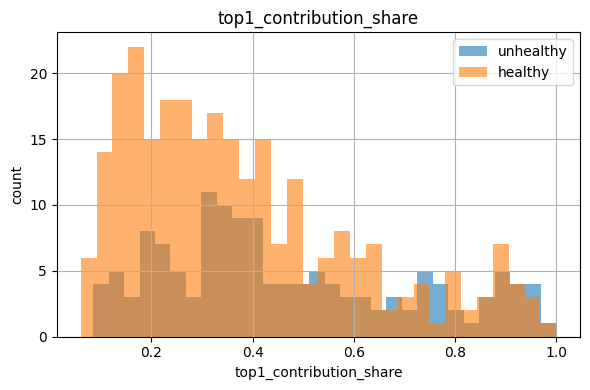

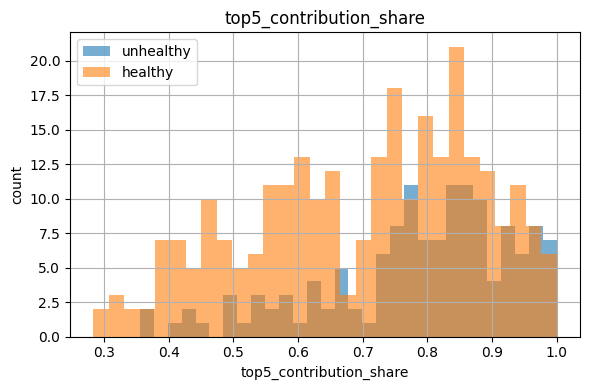

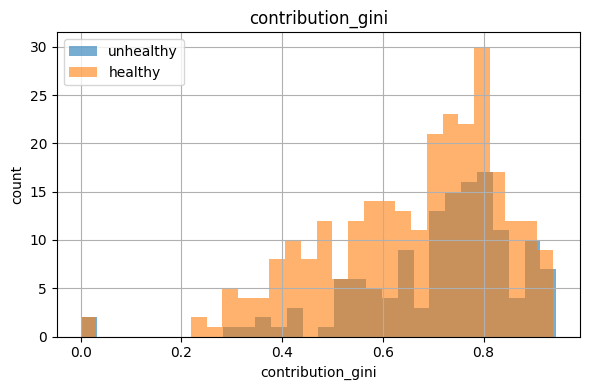

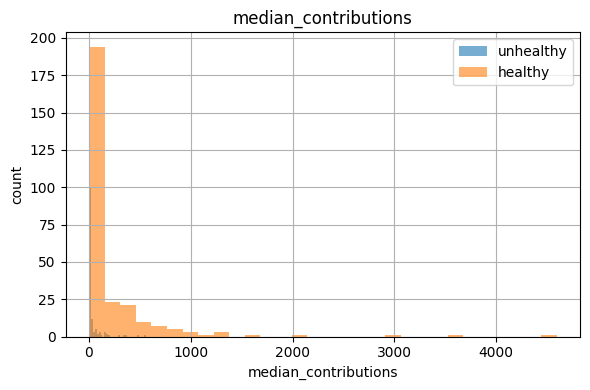

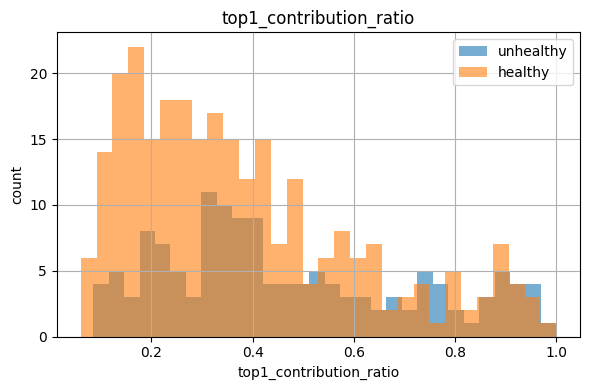

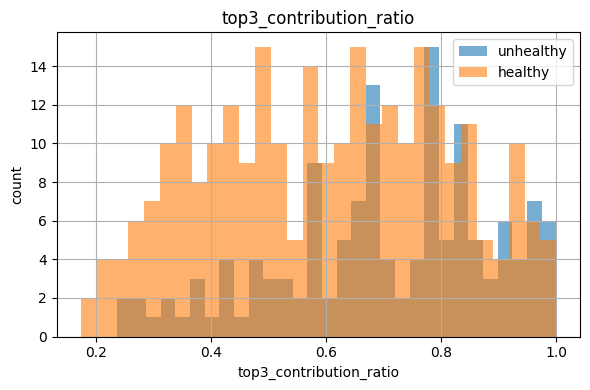

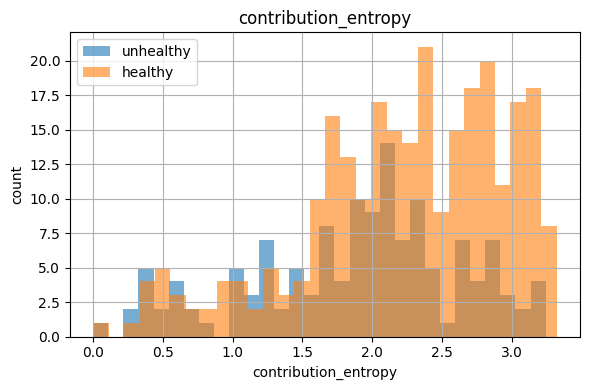

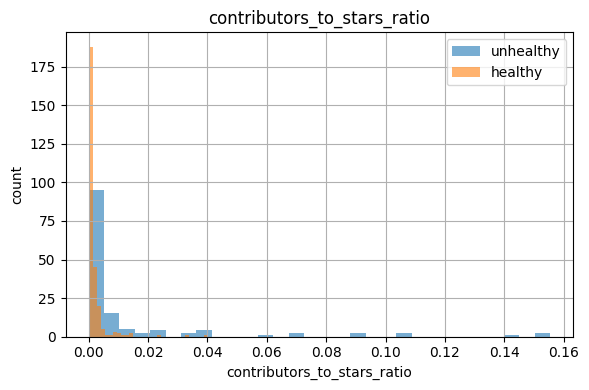

In [17]:
for feature in contributor_features:
    plt.figure(figsize=(6, 4))

    contributor_df.loc[
        contributor_df["label"] == 0, feature
    ].dropna().hist(alpha=0.6, bins=30, label="unhealthy")

    contributor_df.loc[
        contributor_df["label"] == 1, feature
    ].dropna().hist(alpha=0.6, bins=30, label="healthy")

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

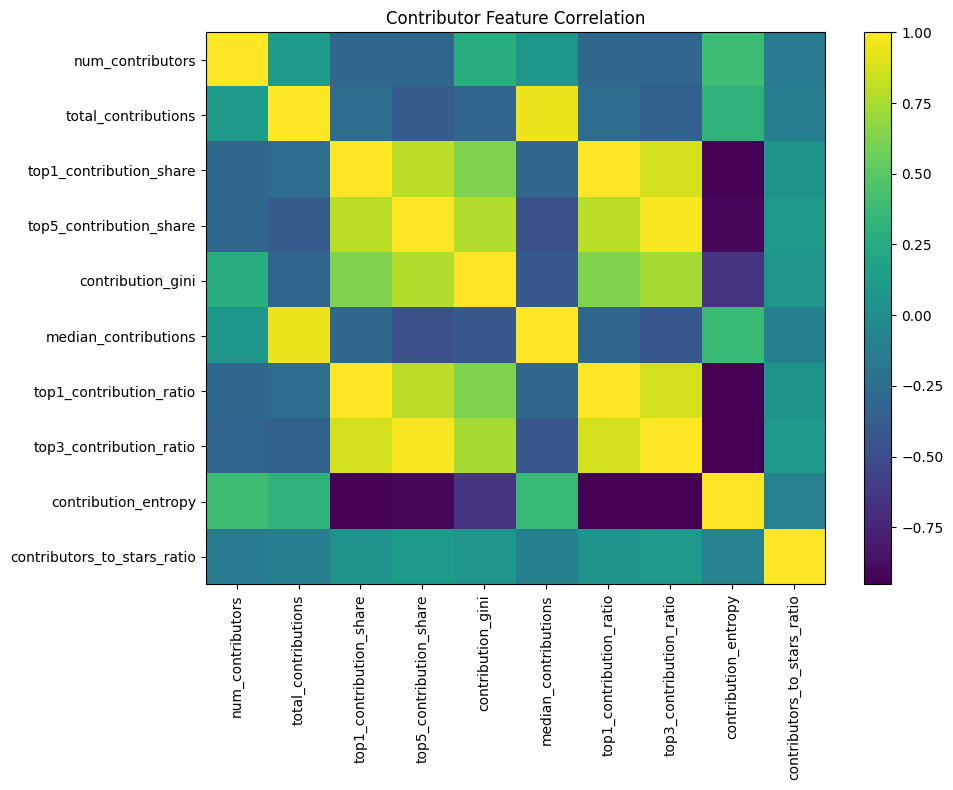

In [18]:
corr_df = contributor_df[contributor_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect="auto")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.colorbar()
plt.title("Contributor Feature Correlation")
plt.tight_layout()
plt.show()

In [19]:
summary.sort_values(
    by="mean_diff_healthy_minus_unhealthy",
    ascending=False
)

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
total_contributions,3546.299270,13445.981618,1666.000000,6053.000000,9899.682348,4387.000000
median_contributions,37.105839,209.253676,7.500000,40.000000,172.147837,32.500000
num_contributors,27.715328,29.540441,30.000000,30.000000,1.825113,0.000000
contribution_entropy,1.878744,2.228391,2.008609,2.329305,0.349647,0.320696
contributors_to_stars_ratio,0.012369,0.001857,0.001853,0.000878,-0.010513,-0.000975
contribution_gini,0.713175,0.659995,0.751116,0.707673,-0.053180,-0.043443
top5_contribution_share,0.787410,0.702931,0.819277,0.738417,-0.084480,-0.080860
top1_contribution_share,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top1_contribution_ratio,0.469759,0.378415,0.408476,0.323672,-0.091344,-0.084805
top3_contribution_ratio,0.703278,0.602344,0.711316,0.608311,-0.100934,-0.103005


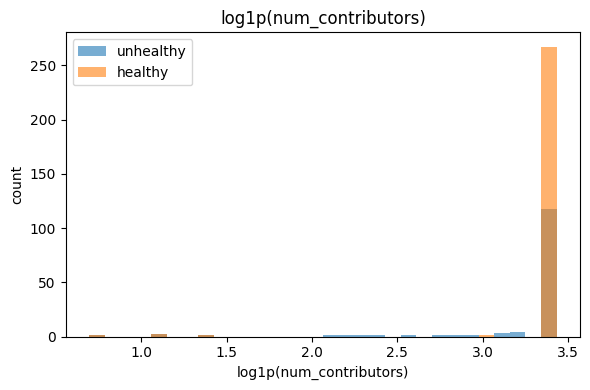

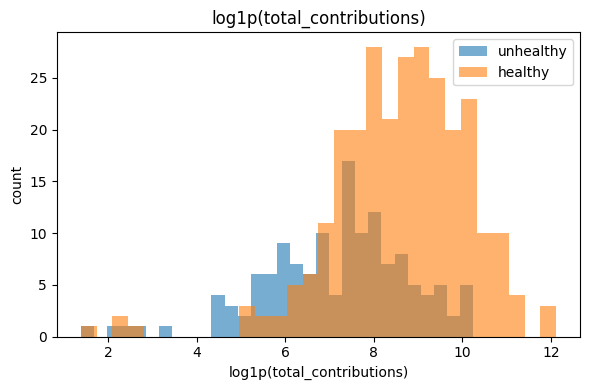

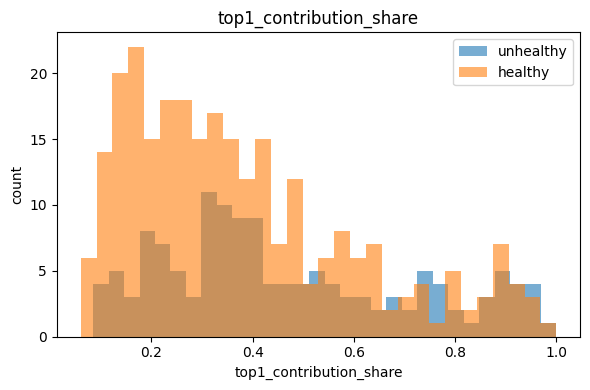

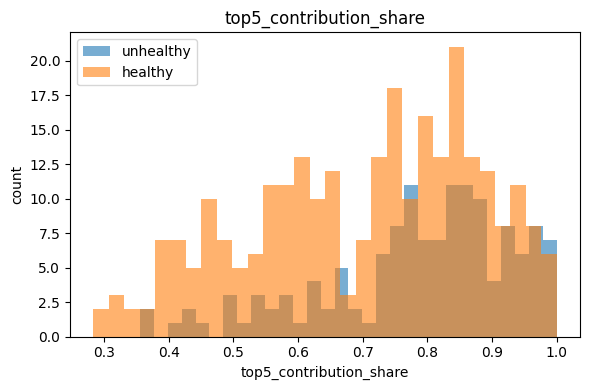

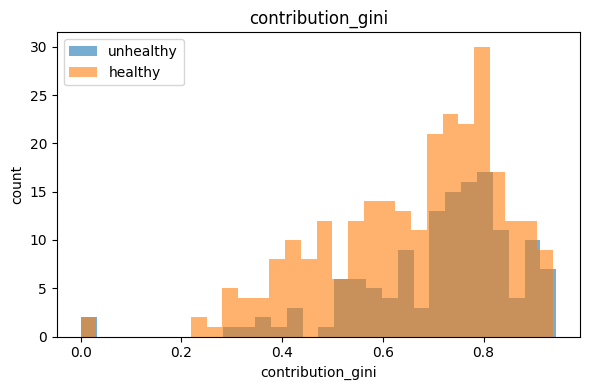

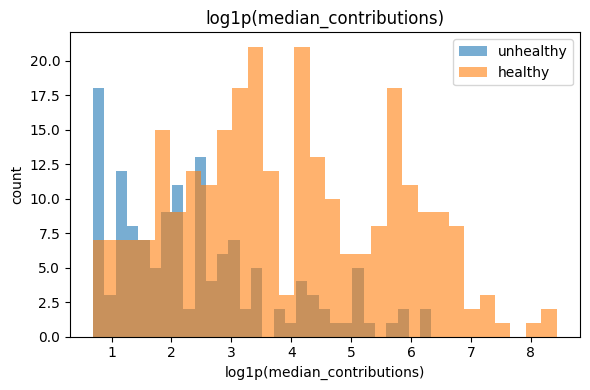

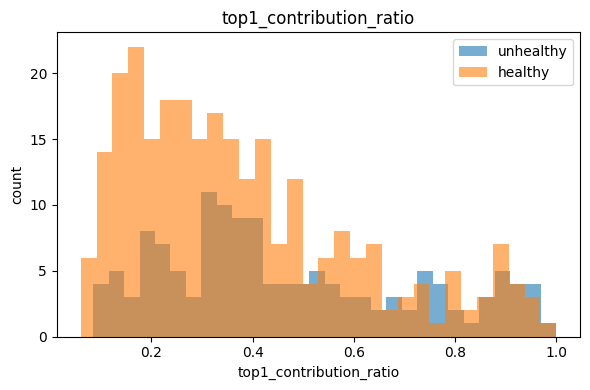

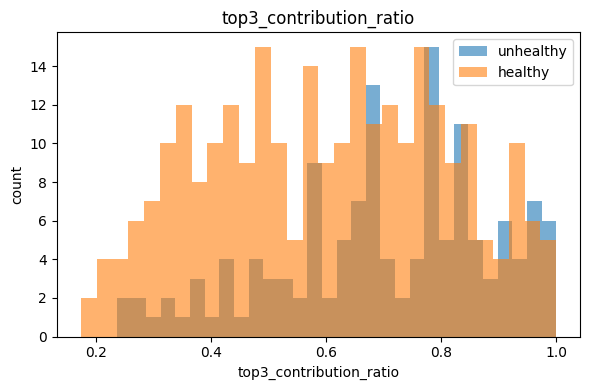

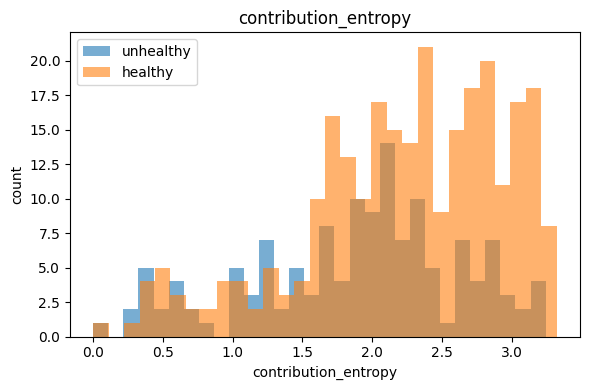

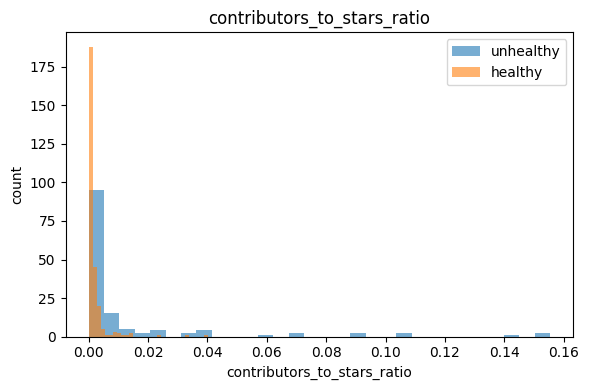

In [20]:
import numpy as np
import matplotlib.pyplot as plt

log_transform_features = [
    "total_contributions",
    "median_contributions",
    "num_contributors",
]

for feature in contributor_features:
    plt.figure(figsize=(6, 4))

    unhealthy_data = contributor_df.loc[
        contributor_df["label"] == 0, feature
    ].dropna()

    healthy_data = contributor_df.loc[
        contributor_df["label"] == 1, feature
    ].dropna()

    if feature in log_transform_features:
        unhealthy_data = np.log1p(unhealthy_data)
        healthy_data = np.log1p(healthy_data)

    plt.hist(
        unhealthy_data,
        bins=30,
        alpha=0.6,
        label="unhealthy"
    )

    plt.hist(
        healthy_data,
        bins=30,
        alpha=0.6,
        label="healthy"
    )

    if feature in log_transform_features:
        plt.title(f"log1p({feature})")
        plt.xlabel(f"log1p({feature})")
    else:
        plt.title(feature)
        plt.xlabel(feature)

    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

---

## **2. Deployment / Release Maturity**

**의미**

“실제로 운영·배포되는 OSS인가”

**핵심 질문**
- release 체계가 안정적인가?
- semantic versioning 잘 지키는가?
- deployment 활동이 존재하는가?

| 컬럼명                          | 의미                                   | 해석                            |
| ---------------------------- | ------------------------------------ | ----------------------------- |
| `num_deployments`            | deployment 기록 수                      | 실제 운영·배포 활동 빈도를 의미            |
| `has_deployments`            | deployment 존재 여부                     | CI/CD 또는 운영 환경 사용 여부를 나타냄     |
| `num_unique_refs`            | deployment에 사용된 고유 ref(branch/tag) 수 | 다양한 release/version 운영 여부를 의미 |
| `tag_based_deployment_ratio` | tag 기반 deployment 비율                 | 정식 release 중심 운영 여부를 나타냄      |
| `deployment_recency_days`    | 마지막 deployment 이후 경과 일수              | 최근까지 운영·배포가 유지되는지 반영          |
| `num_tags`                   | 전체 tag 수                             | release/version 관리 활동 규모를 의미  |
| `stable_tag_ratio`           | stable release tag 비율                | 안정 버전 중심 release 구조 여부를 나타냄   |
| `prerelease_tag_ratio`       | prerelease(alpha/beta/rc) tag 비율     | 실험적·개발 단계 release 비중을 의미      |
| `latest_tag_is_stable`       | 최신 tag가 stable 여부                    | 현재 release 상태가 안정 버전인지 나타냄    |
| `latest_tag_is_prerelease`   | 최신 tag가 prerelease 여부                | 현재 개발·실험 단계 release인지 반영      |
| `semver_tag_ratio`           | semantic versioning 규칙을 따르는 tag 비율   | 체계적인 버전 관리 수준을 의미             |
| `num_major_versions`         | major version 수                      | 장기적인 프로젝트 진화·확장 정도를 나타냄       |
| `num_minor_versions`         | minor version 수                      | 세부 기능 업데이트 및 유지보수 빈도를 의미      |
| `tag_release_velocity`       | 단위 시간당 tag 생성 속도                     | release/update 주기의 활발함을 의미    |


In [21]:
release_features = [
    "num_deployments",
    "has_deployments",
    "num_unique_refs",
    "tag_based_deployment_ratio",
    "deployment_recency_days",
    "num_tags",
    "stable_tag_ratio",
    "prerelease_tag_ratio",
    "latest_tag_is_stable",
    "latest_tag_is_prerelease",
    "semver_tag_ratio",
    "num_major_versions",
    "num_minor_versions",
    "tag_release_velocity",
]

In [22]:
release_df = df[release_features + ["label"]].copy()

for col in release_features:
    release_df[col] = pd.to_numeric(
        release_df[col],
        errors="coerce"
    )

summary_mean = (
    release_df
    .groupby("label")[release_features]
    .mean()
    .T
)

summary_median = (
    release_df
    .groupby("label")[release_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_deployments,9.598540,15.602941,0.000000,20.000000,6.004401,20.000000
has_deployments,0.401460,0.610294,0.000000,1.000000,0.208834,1.000000
num_unique_refs,4.445255,7.014706,0.000000,1.000000,2.569450,1.000000
tag_based_deployment_ratio,0.021898,0.063509,0.000000,0.000000,0.041611,0.000000
deployment_recency_days,388.132897,341.474305,0.000000,0.232074,-46.658592,0.232074
num_tags,17.452555,25.161765,27.000000,30.000000,7.709210,3.000000
stable_tag_ratio,0.434814,0.566090,0.300000,0.700000,0.131276,0.400000
prerelease_tag_ratio,0.119535,0.153006,0.000000,0.000000,0.033471,0.000000
latest_tag_is_stable,0.445255,0.540441,0.000000,1.000000,0.095186,1.000000
latest_tag_is_prerelease,0.058394,0.136029,0.000000,0.000000,0.077635,0.000000


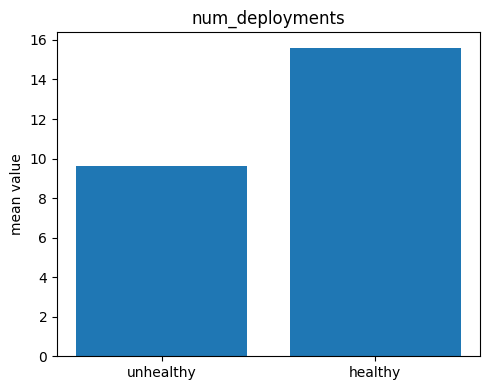

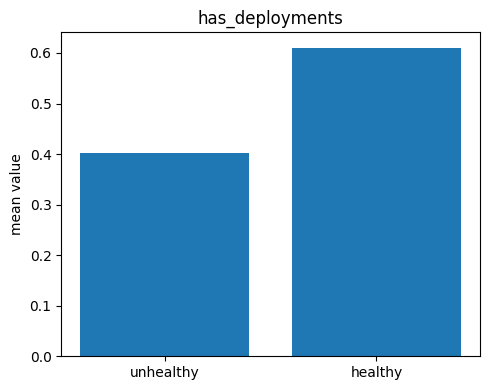

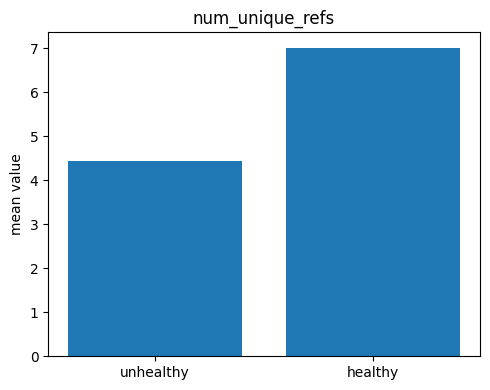

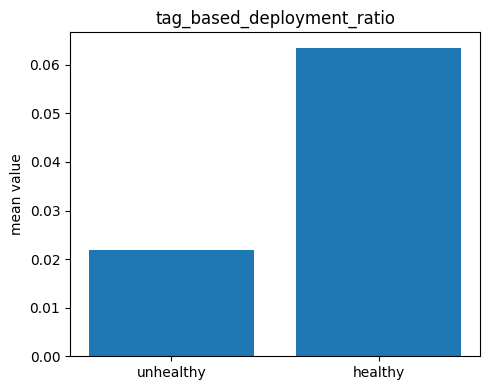

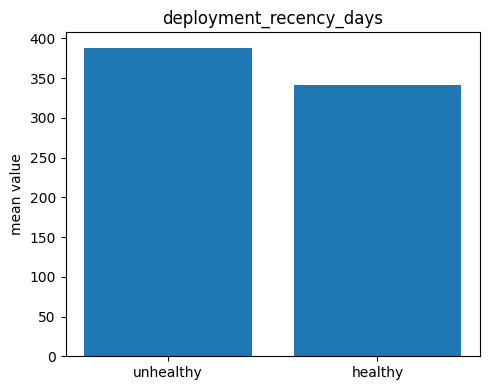

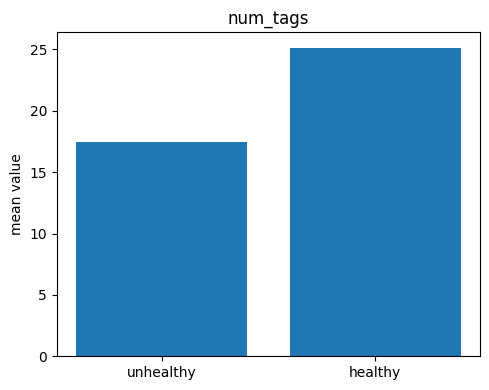

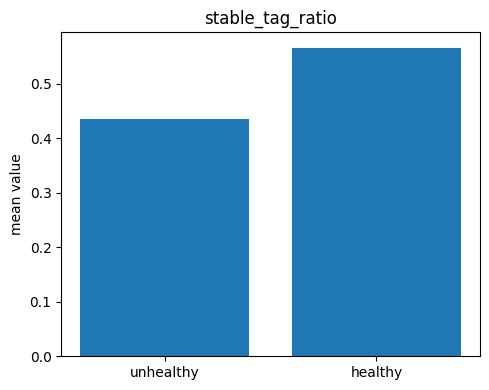

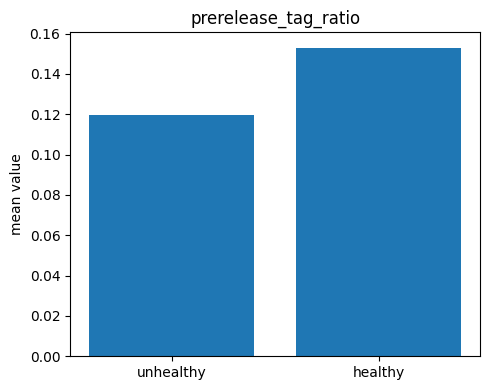

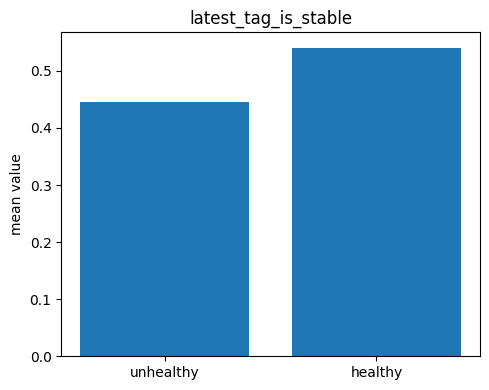

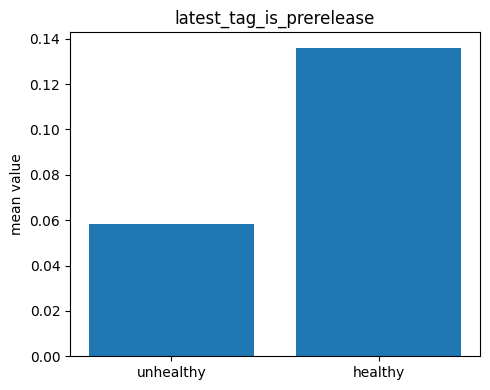

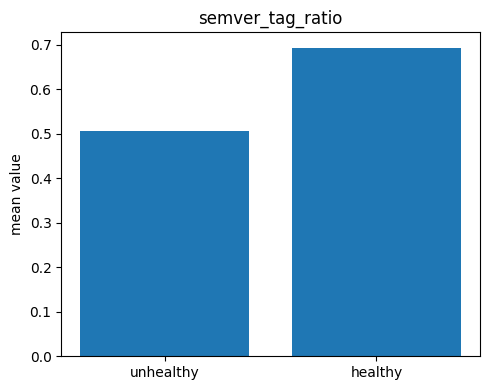

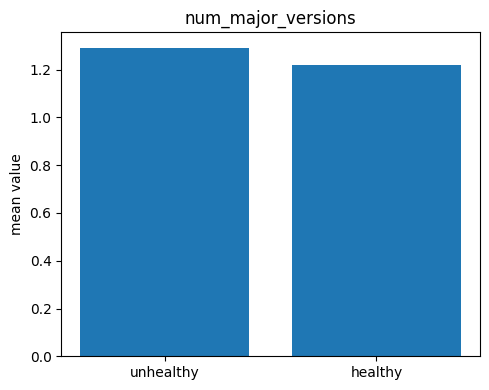

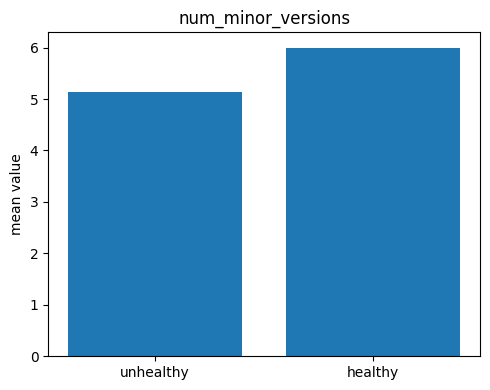

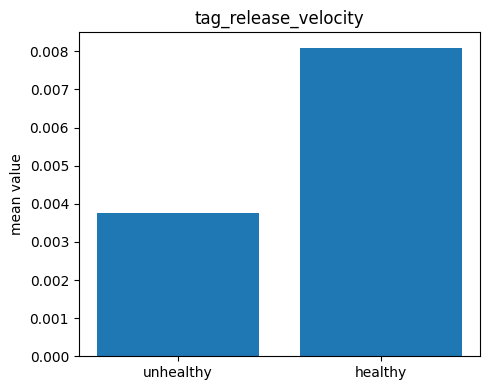

In [23]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


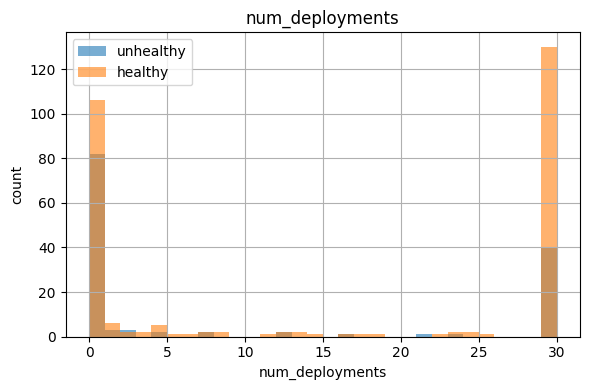

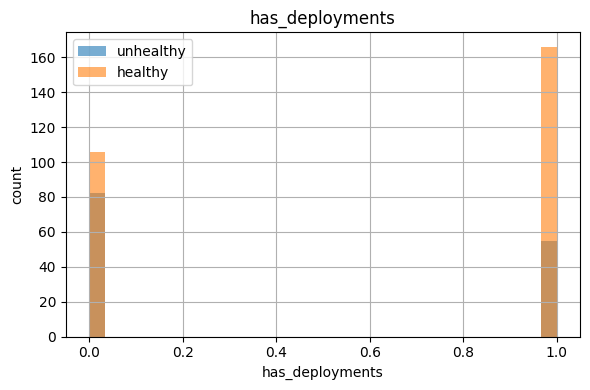

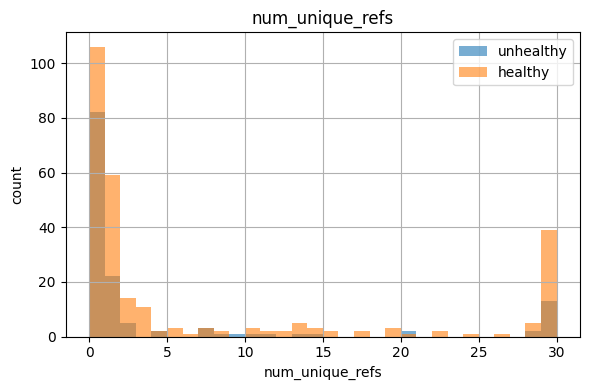

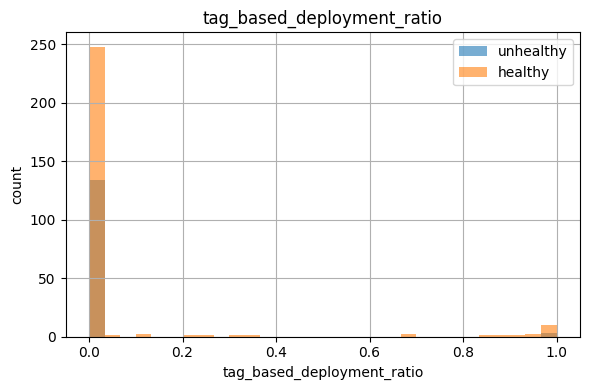

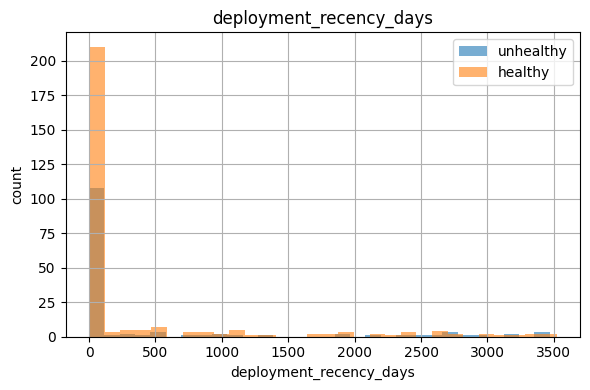

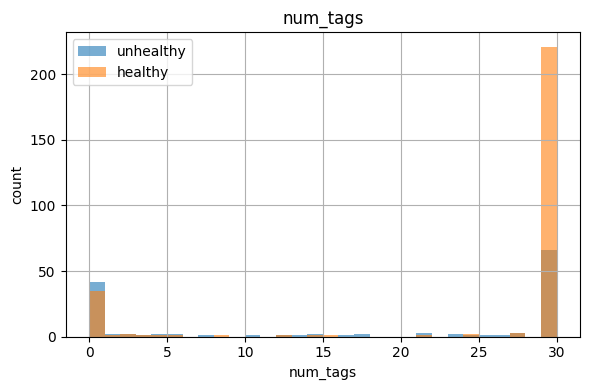

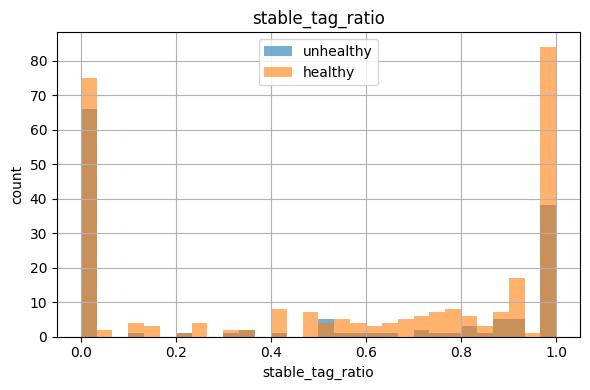

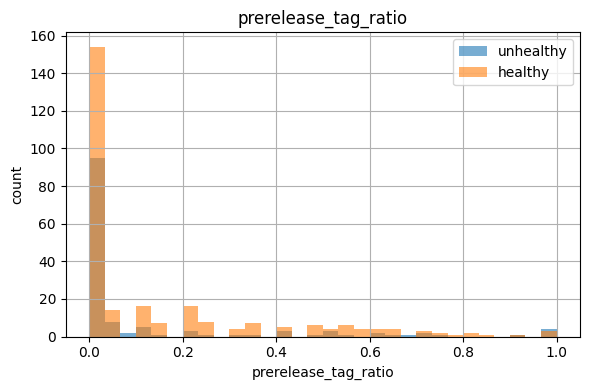

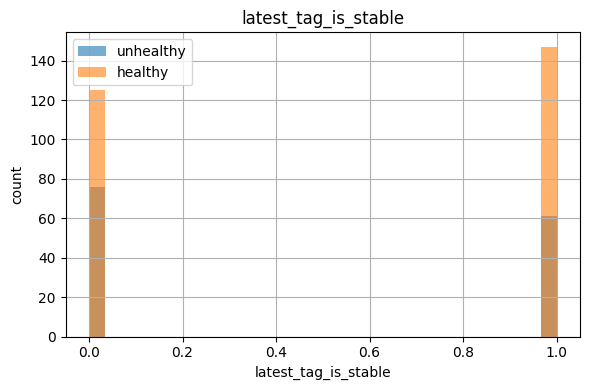

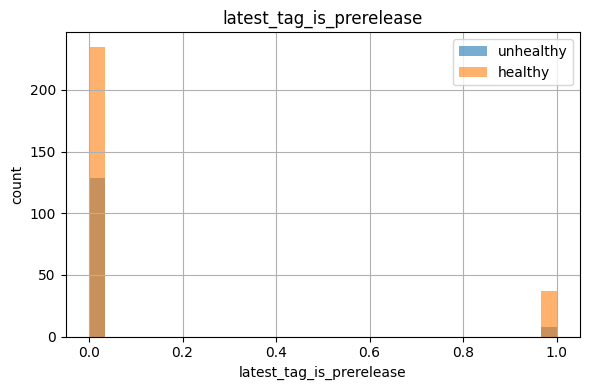

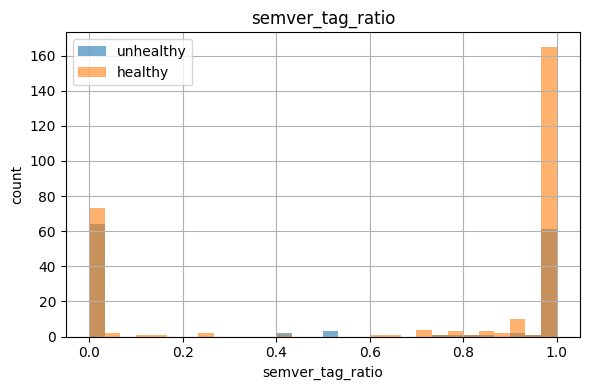

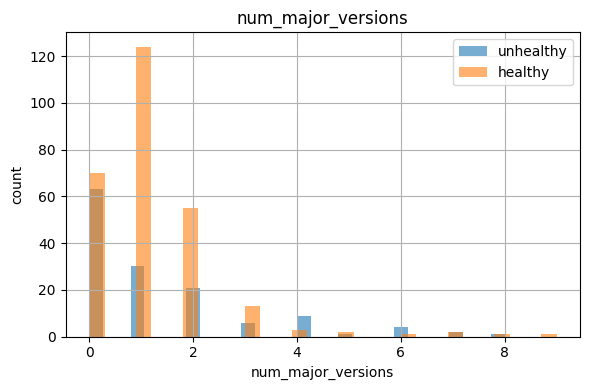

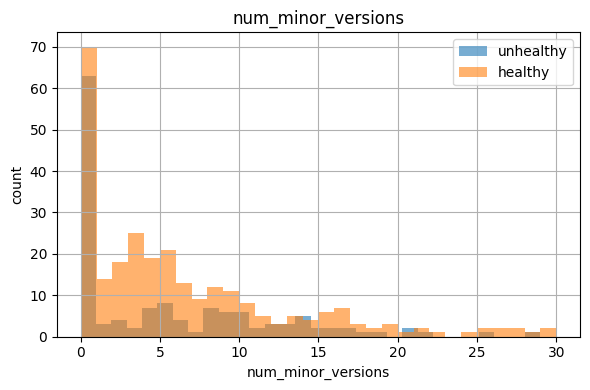

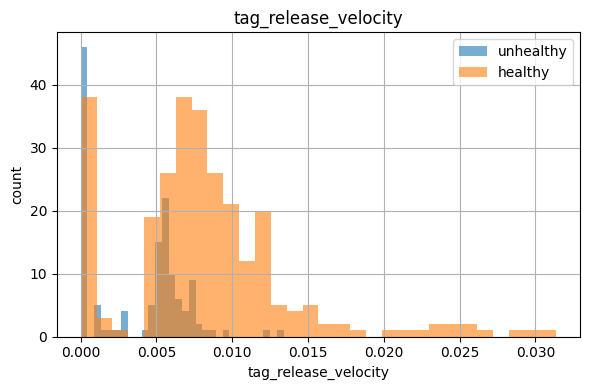

In [24]:
for feature in release_features:

    plt.figure(figsize=(6, 4))

    (
        release_df.loc[
            release_df["label"] == 0,
            feature
        ]
        .dropna()
        .hist(
            alpha=0.6,
            bins=30,
            label="unhealthy"
        )
    )

    (
        release_df.loc[
            release_df["label"] == 1,
            feature
        ]
        .dropna()
        .hist(
            alpha=0.6,
            bins=30,
            label="healthy"
        )
    )

    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("count")

    plt.legend()

    plt.tight_layout()
    plt.show()

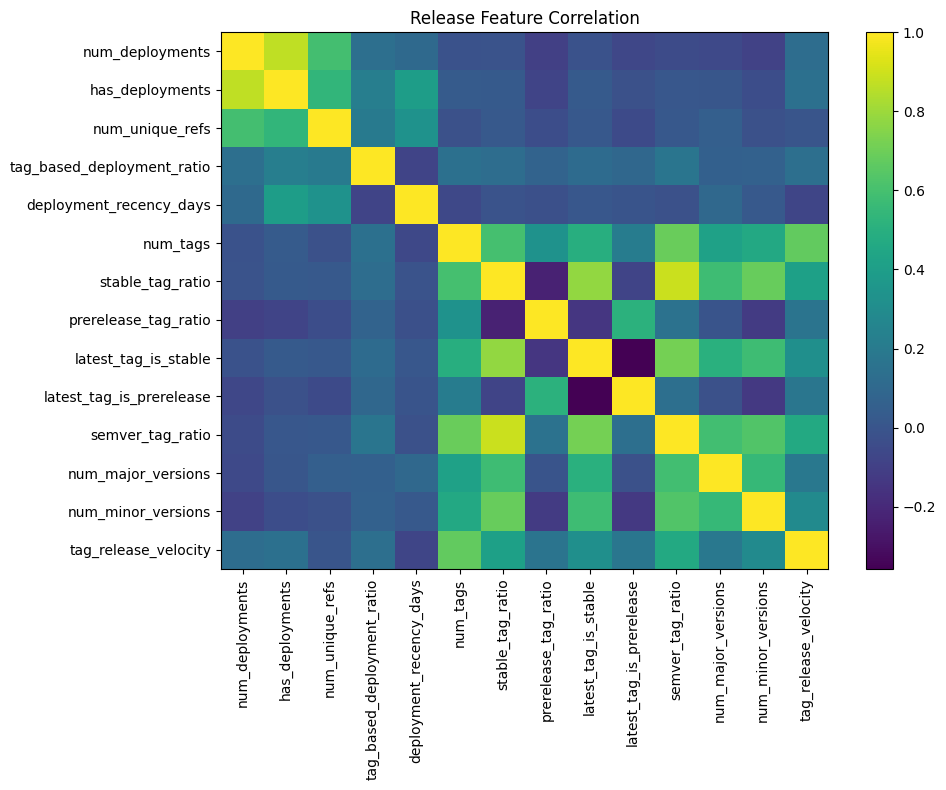

In [25]:
corr_df = (
    release_df[release_features]
    .corr()
)

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_df,
    aspect="auto"
)

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_df.index)),
    corr_df.index
)

plt.colorbar()

plt.title("Release Feature Correlation")

plt.tight_layout()
plt.show()

In [26]:
summary.sort_values(
    by="mean_diff_healthy_minus_unhealthy",
    ascending=False
)

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_tags,17.452555,25.161765,27.000000,30.000000,7.709210,3.000000
num_deployments,9.598540,15.602941,0.000000,20.000000,6.004401,20.000000
num_unique_refs,4.445255,7.014706,0.000000,1.000000,2.569450,1.000000
num_minor_versions,5.145985,5.996324,2.000000,4.000000,0.850338,2.000000
has_deployments,0.401460,0.610294,0.000000,1.000000,0.208834,1.000000
semver_tag_ratio,0.504984,0.692993,0.529412,1.000000,0.188009,0.470588
stable_tag_ratio,0.434814,0.566090,0.300000,0.700000,0.131276,0.400000
latest_tag_is_stable,0.445255,0.540441,0.000000,1.000000,0.095186,1.000000
latest_tag_is_prerelease,0.058394,0.136029,0.000000,0.000000,0.077635,0.000000
tag_based_deployment_ratio,0.021898,0.063509,0.000000,0.000000,0.041611,0.000000


## **3. Activity / Event Dynamics**

**의미**

“프로젝트가 실제로 살아 움직이는가”

**핵심 질문**
- interaction 활발한가?
- 개발 이벤트 중심인가?
- 단순 인기 repo인가?

| 컬럼명                             | 의미                                 | 해석                           |
| ------------------------------- | ---------------------------------- | ---------------------------- |
| `num_events`                    | 전체 GitHub event 수                  | 프로젝트 활동량 및 사용자 반응 규모를 의미     |
| `num_unique_event_types`        | 등장한 event 종류 수                     | 프로젝트 활동 유형의 다양성을 나타냄         |
| `dominant_event_ratio`          | 가장 많이 발생한 event 유형의 비율             | 특정 활동 유형에 편중된 정도를 의미         |
| `event_type_entropy`            | event 유형 분포의 entropy               | 활동 구조의 다양성과 균형 정도를 나타냄       |
| `has_IssuesEvent`               | IssuesEvent 존재 여부                  | issue 생성·관리 활동 존재 여부를 의미     |
| `has_PullRequestEvent`          | PullRequestEvent 존재 여부             | PR 기반 협업 개발 활동 존재 여부를 의미     |
| `has_IssueCommentEvent`         | IssueCommentEvent 존재 여부            | issue 토론 및 커뮤니케이션 활동 여부를 나타냄 |
| `recent_event_density`          | 최근 event 발생 밀도                     | 최근까지 프로젝트 활동이 유지되는 정도를 의미    |
| `IssuesEvent_ratio`             | 전체 event 중 IssuesEvent 비율          | issue 기반 관리 활동 비중을 나타냄       |
| `IssueCommentEvent_ratio`       | 전체 event 중 IssueCommentEvent 비율    | 커뮤니케이션·토론 활동 비중을 의미          |
| `PullRequestEvent_ratio`        | 전체 event 중 PullRequestEvent 비율     | 협업 기반 코드 기여 활동 비중을 의미        |
| `PushEvent_ratio`               | 전체 event 중 PushEvent 비율            | 실제 코드 업데이트 활동 비중을 의미         |
| `WatchEvent_ratio`              | 전체 event 중 WatchEvent 비율           | 사용자 관심·구독 활동 비중을 의미          |
| `ForkEvent_ratio`               | 전체 event 중 ForkEvent 비율            | 프로젝트 재사용·파생 개발 관심도를 나타냄      |
| `interaction_ratio`             | 상호작용(event 기반 communication) 관련 비율 | 사용자·개발자 간 커뮤니티 상호작용 수준을 의미   |
| `development_ratio`             | 개발 활동 중심 event 비율                  | 실제 코드 개발·유지보수 활동 중심성을 의미     |
| `external_interest_event_ratio` | 외부 관심 기반 event 비율                  | 사용자 관심·인기 중심 활동 비중을 나타냄      |


In [27]:
event_features = [
    "num_events",
    "num_unique_event_types",
    "dominant_event_ratio",
    "event_type_entropy",
    "has_IssuesEvent",
    "has_PullRequestEvent",
    "has_IssueCommentEvent",
    "recent_event_density",
    "IssuesEvent_ratio",
    "IssueCommentEvent_ratio",
    "PullRequestEvent_ratio",
    "PushEvent_ratio",
    "WatchEvent_ratio",
    "ForkEvent_ratio",
    "interaction_ratio",
    "development_ratio",
    "external_interest_event_ratio",
]

In [28]:
event_df = df[event_features + ["label"]].copy()

for col in event_features:
    event_df[col] = pd.to_numeric(
        event_df[col],
        errors="coerce"
    )

summary_mean = (
    event_df
    .groupby("label")[event_features]
    .mean()
    .T
)

summary_median = (
    event_df
    .groupby("label")[event_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
num_events,18.781022,28.441176,28.000000,30.000000,9.660155,2.000000
num_unique_event_types,3.007299,5.702206,3.000000,6.000000,2.694907,3.000000
dominant_event_ratio,0.583461,0.491450,0.633333,0.413793,-0.092011,-0.219540
event_type_entropy,0.645274,1.320618,0.540204,1.499143,0.675344,0.958939
has_IssuesEvent,0.182482,0.430147,0.000000,0.000000,0.247665,0.000000
has_PullRequestEvent,0.364964,0.779412,0.000000,1.000000,0.414448,1.000000
has_IssueCommentEvent,0.335766,0.783088,0.000000,1.000000,0.447322,1.000000
recent_event_density,24.704742,127.094145,1.000000,23.306855,102.389404,22.306855
IssuesEvent_ratio,0.018180,0.049395,0.000000,0.000000,0.031215,0.000000
IssueCommentEvent_ratio,0.041542,0.140388,0.000000,0.103448,0.098846,0.103448


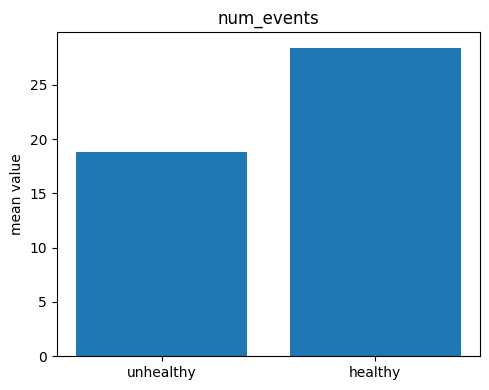

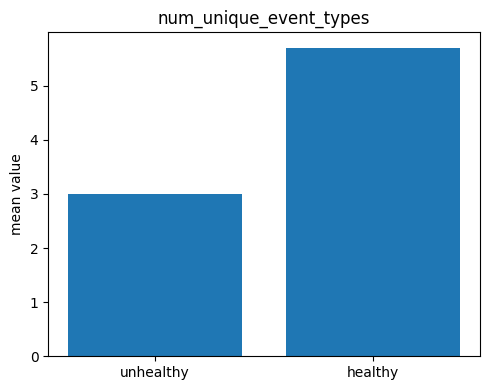

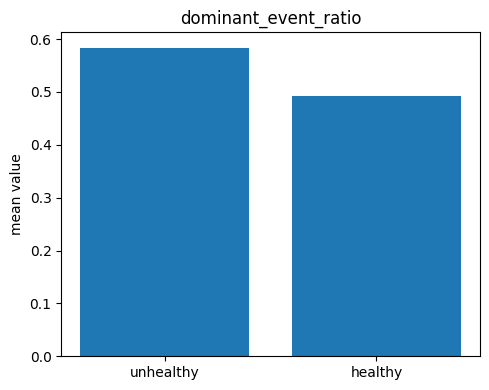

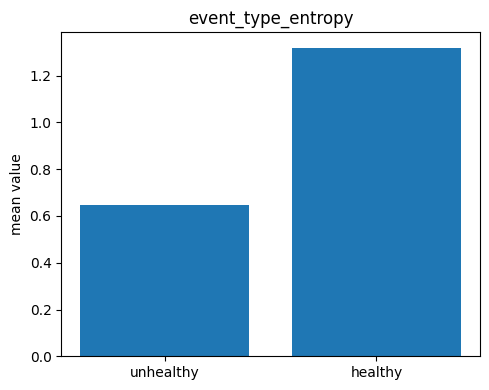

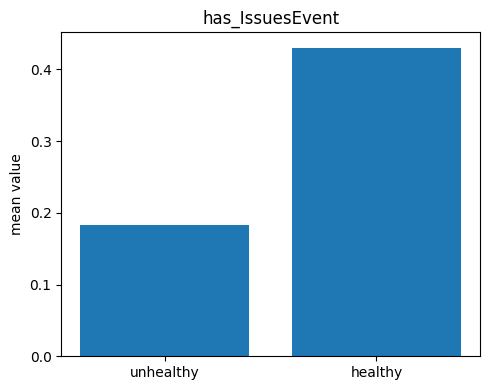

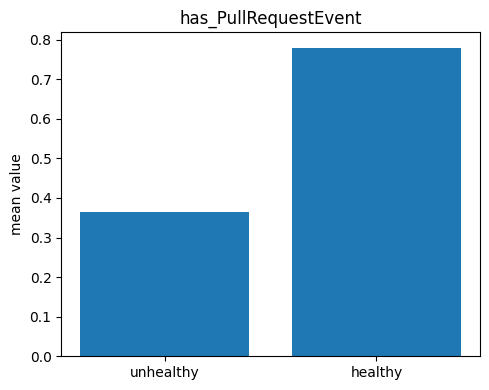

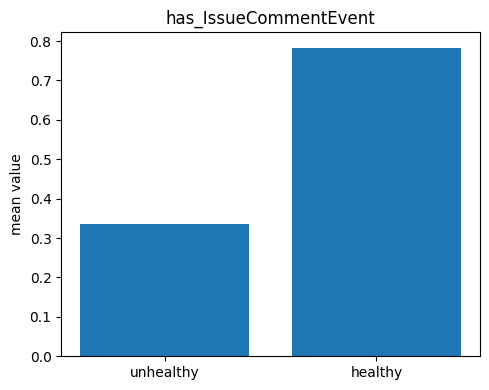

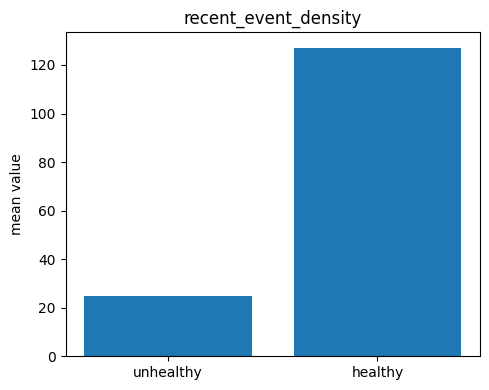

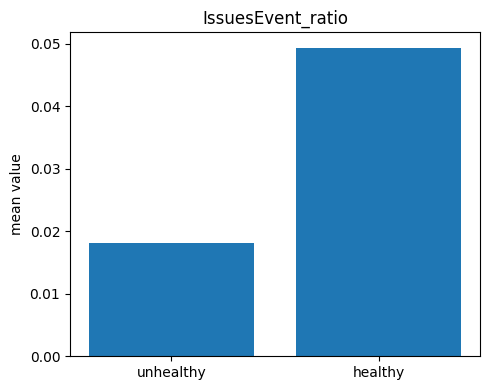

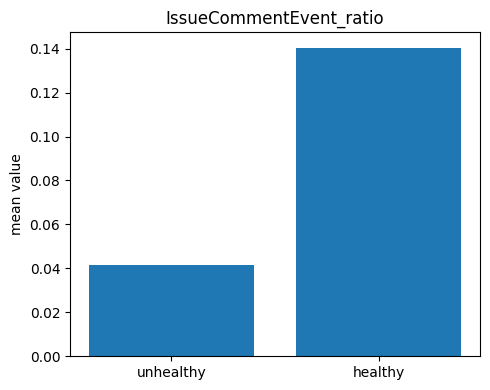

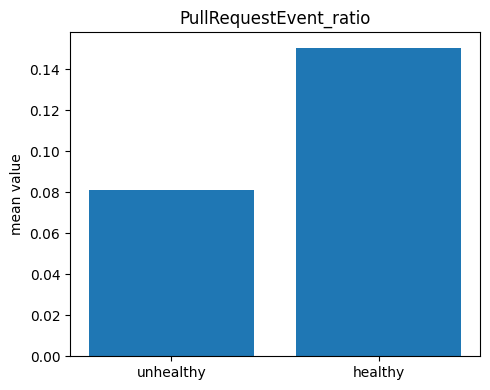

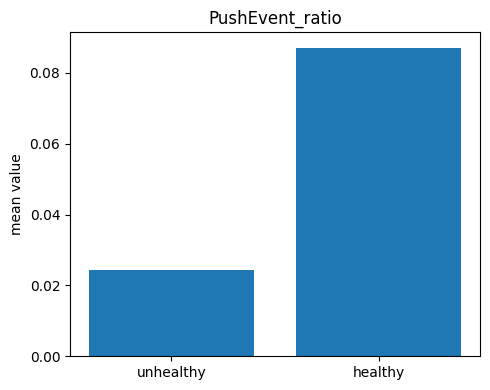

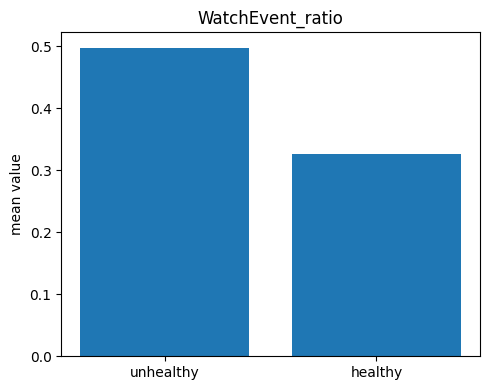

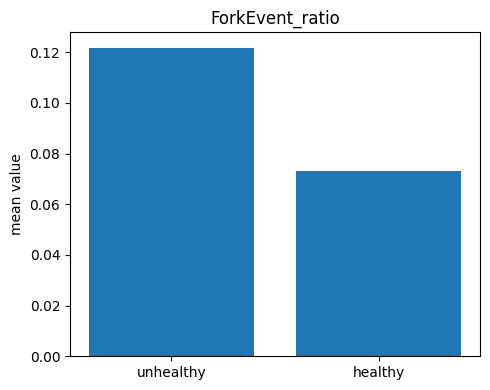

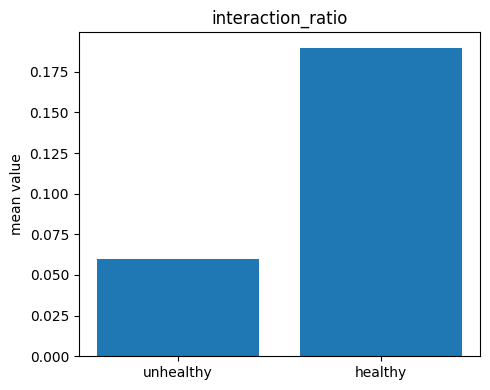

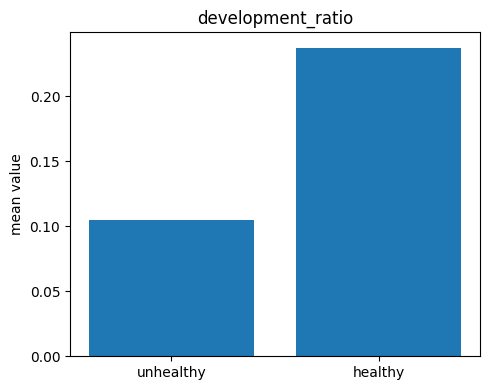

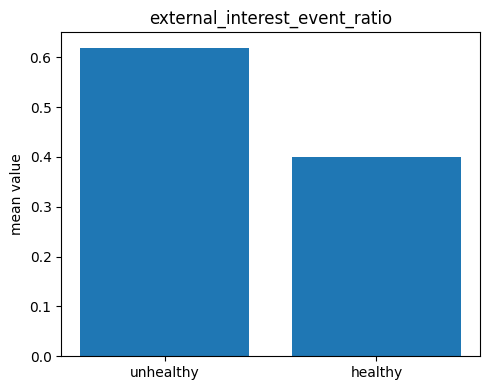

In [29]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


## **4. Popularity / Ecosystem Interest**

**의미**

“얼마나 주목받는가”

**핵심 질문**
- popularity와 health는 같은가?
- star inflation 존재하는가?

| 컬럼명                          | 의미                               | 해석                                    |
| ---------------------------- | -------------------------------- | ------------------------------------- |
| `stargazers_count`           | GitHub star 수                    | 프로젝트의 전체적인 인기와 관심도를 의미                |
| `subscribers_count`          | repository subscriber(watcher) 수 | 지속적으로 프로젝트를 관찰·추적하는 사용자 규모를 의미        |
| `subscribers_to_stars_ratio` | subscriber 대비 star 비율            | 단순 인기보다 실제 지속 관심 사용자 비중을 나타냄          |
| `forks_count`                | fork 수                           | 프로젝트 재사용·확장·파생 개발 정도를 의미              |
| `network_count`              | 전체 fork network 규모               | 프로젝트 생태계 및 파생 구조의 확장성을 나타냄            |
| `forks_to_stars_ratio`       | star 대비 fork 비율                  | 관심 대비 실제 활용·수정 참여 정도를 의미              |
| `open_issues_to_stars_ratio` | star 대비 open issue 비율            | 사용자 규모 대비 unresolved issue 부담 정도를 나타냄 |
| `stars_per_repo_age_day`     | repo 생성 이후 하루당 star 증가량          | 시간 대비 인기 성장 속도를 의미                    |
| `forks_per_repo_age_day`     | repo 생성 이후 하루당 fork 증가량          | 시간 대비 활용·재사용 성장 속도를 의미                |
| `stars_per_size`             | repo 크기 대비 star 수                | 코드 규모 대비 관심 집중도를 나타냄                  |
| `forks_per_size`             | repo 크기 대비 fork 수                | 코드 규모 대비 실제 활용·확장 정도를 의미              |


In [30]:
popularity_features = [
    "stargazers_count",
    "subscribers_count",
    "subscribers_to_stars_ratio",
    "forks_count",
    "network_count",
    "forks_to_stars_ratio",
    "open_issues_to_stars_ratio",
    "stars_per_repo_age_day",
    "forks_per_repo_age_day",
    "stars_per_size",
    "forks_per_size",
]

In [31]:
popular_df = df[popularity_features + ["label"]].copy()

for col in popularity_features:
    popular_df[col] = pd.to_numeric(
        popular_df[col],
        errors="coerce"
    )

summary_mean = (
    popular_df
    .groupby("label")[popularity_features]
    .mean()
    .T
)

summary_median = (
    popular_df
    .groupby("label")[popularity_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
stargazers_count,59276.262774,59723.632353,14786.000000,33602.500000,447.369579,18816.500000
subscribers_count,1237.598540,1049.797794,336.000000,433.500000,-187.800746,97.500000
subscribers_to_stars_ratio,0.034849,0.019454,0.024645,0.013371,-0.015395,-0.011274
forks_count,10697.620438,10659.639706,2465.000000,4695.500000,-37.980732,2230.500000
network_count,10700.328467,10659.639706,2465.000000,4695.500000,-40.688761,2230.500000
forks_to_stars_ratio,0.540896,0.330415,0.185694,0.140727,-0.210481,-0.044967
open_issues_to_stars_ratio,0.051142,0.041451,0.008441,0.015004,-0.009692,0.006563
stars_per_repo_age_day,16.631661,18.900708,3.122286,9.668716,2.269047,6.546430
forks_per_repo_age_day,2.940459,3.068502,0.563470,1.339624,0.128043,0.776153
stars_per_size,38.403534,19.635672,0.865691,0.306110,-18.767862,-0.559581


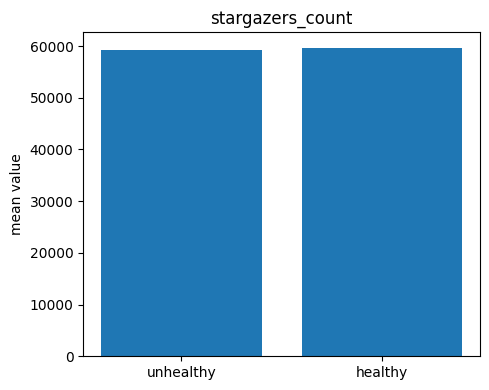

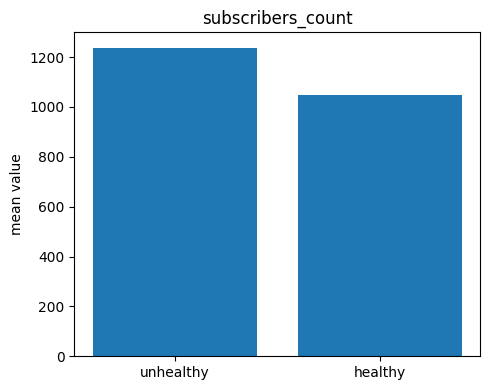

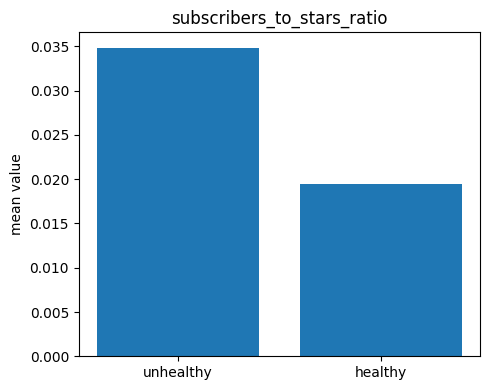

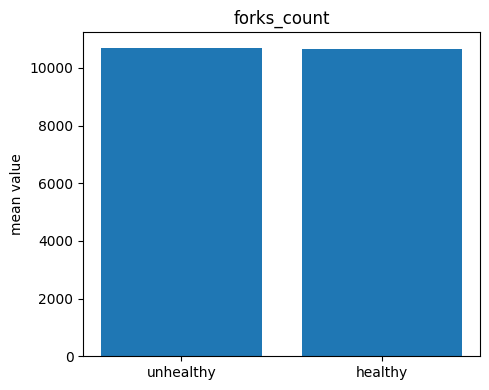

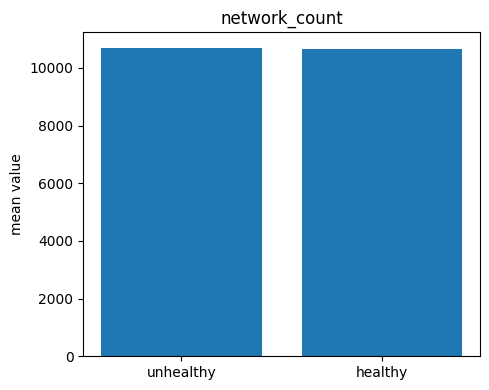

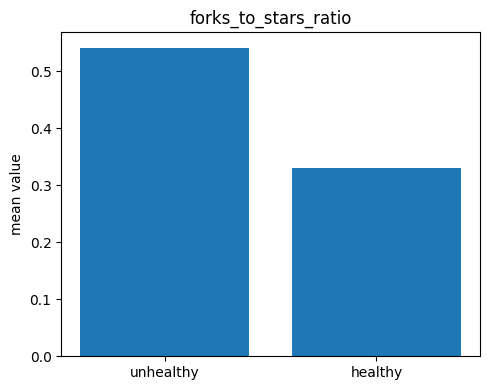

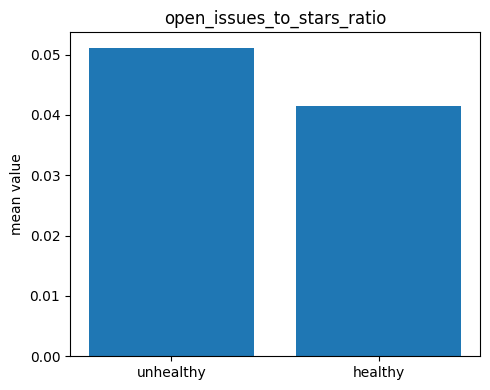

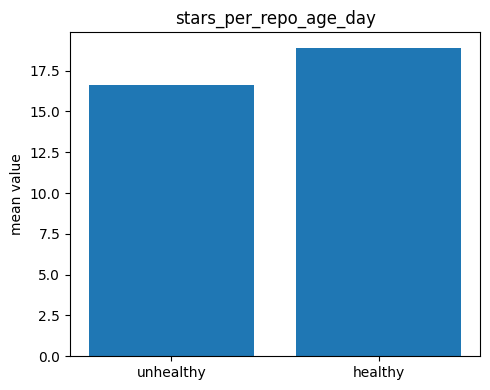

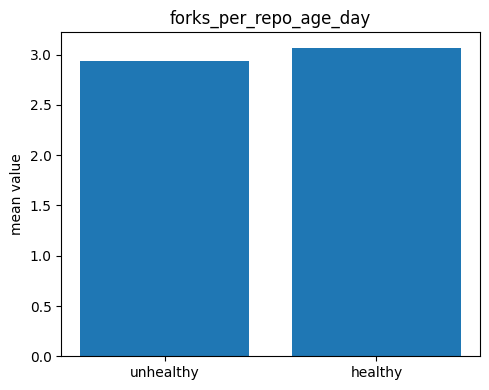

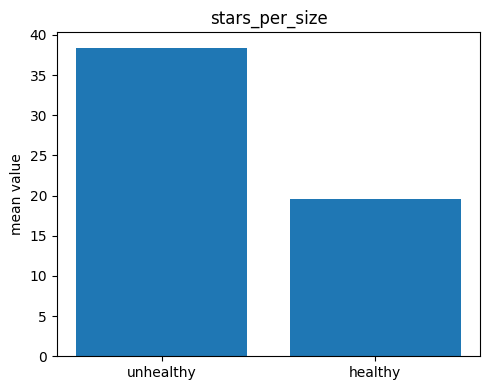

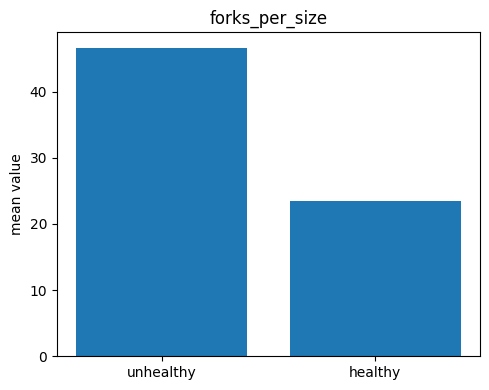

In [32]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


## **5. Language / Architectural Diversity**

**의미**

“프로젝트 구조 복잡성과 기술 다양성”

**핵심 질문**
- 단일 언어 vs multi-language
- infra/system repo 특성 존재?
- architecture complexity 차이?

| 컬럼명                      | 의미                               | 해석                          |
| ------------------------ | -------------------------------- | --------------------------- |
| `primary_language_ratio` | 가장 큰 비중을 차지하는 언어의 비율             | 특정 언어 중심 프로젝트인지 나타냄         |
| `top2_ratio`             | 상위 2개 언어 비율 합                    | 핵심 언어 조합 중심 구조 여부를 의미       |
| `top3_ratio`             | 상위 3개 언어 비율 합                    | 프로젝트 언어 집중도를 나타냄            |
| `language_entropy`       | 언어 분포 entropy                    | 언어 구성의 다양성과 복잡도를 의미         |
| `minor_lang_ratio`       | 소수 언어 비율                         | 보조 언어·스크립트·설정 파일 활용 정도를 나타냄 |
| `infra_ratio`            | Infra/System 계열 언어 비율            | 시스템·인프라 성격 프로젝트 여부를 의미      |
| `markup_ratio`           | HTML/CSS/Template 등 markup 언어 비율 | 문서·웹 UI·설정 중심 구성 여부를 나타냄    |
| `is_monolingual`         | 단일 언어 프로젝트 여부                    | 언어 구조 단순성 여부를 의미            |
| `compiled_ratio`         | 컴파일 언어 비율                        | 성능·시스템 중심 개발 특성을 나타냄        |


In [33]:
language_features = [
    "primary_language_ratio",
    "top2_ratio",
    "top3_ratio",
    "language_entropy",
    "minor_lang_ratio",
    "infra_ratio",
    "markup_ratio",
    "is_monolingual",
    "compiled_ratio",
]

In [34]:
language_df = df[language_features + ["label"]].copy()

for col in language_features:
    language_df[col] = pd.to_numeric(
        language_df[col],
        errors="coerce"
    )

summary_mean = (
    language_df
    .groupby("label")[language_features]
    .mean()
    .T
)

summary_median = (
    language_df
    .groupby("label")[language_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
primary_language_ratio,0.731498,0.801528,0.851635,0.897376,0.070030,0.045741
top2_ratio,0.844040,0.904873,0.984319,0.984382,0.060833,0.000064
top3_ratio,0.873063,0.930393,0.997781,0.995281,0.057330,-0.002500
language_entropy,0.453544,0.441147,0.295194,0.298143,-0.012397,0.002949
minor_lang_ratio,0.166312,0.150678,0.086852,0.072527,-0.015634,-0.014325
infra_ratio,0.013081,0.015063,0.000144,0.001783,0.001981,0.001638
markup_ratio,0.059070,0.019011,0.000551,0.000300,-0.040060,-0.000251
is_monolingual,0.364964,0.422794,0.000000,0.000000,0.057831,0.000000
compiled_ratio,0.133244,0.343662,0.000000,0.002004,0.210418,0.002004


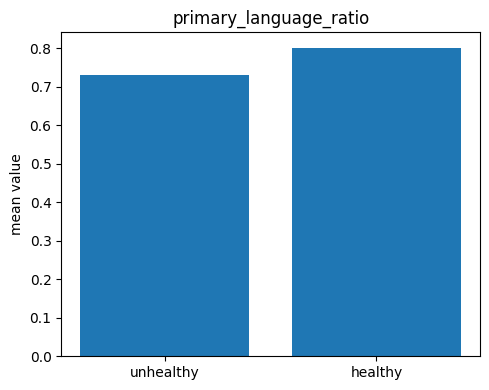

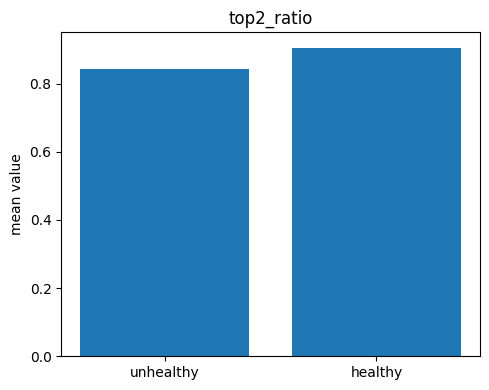

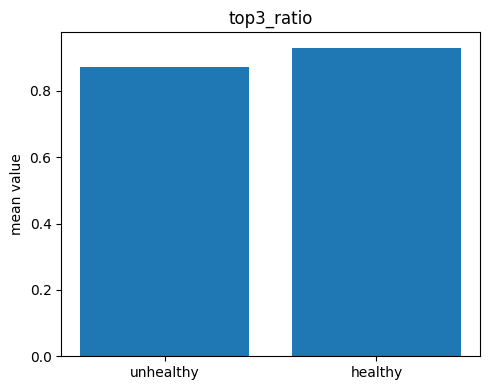

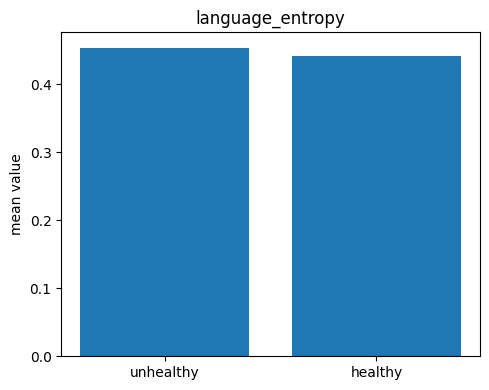

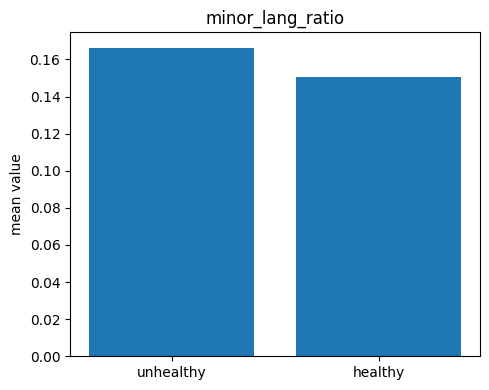

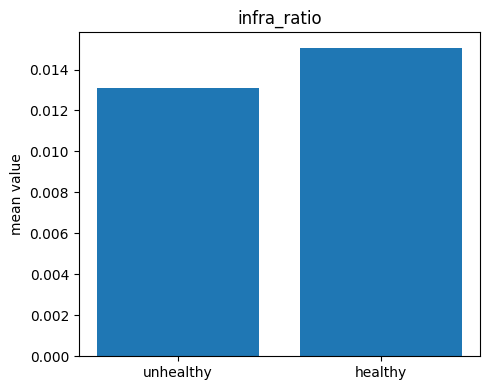

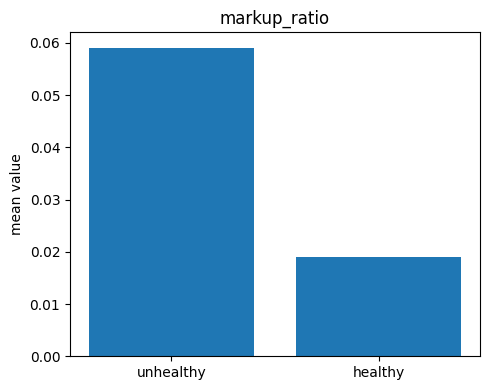

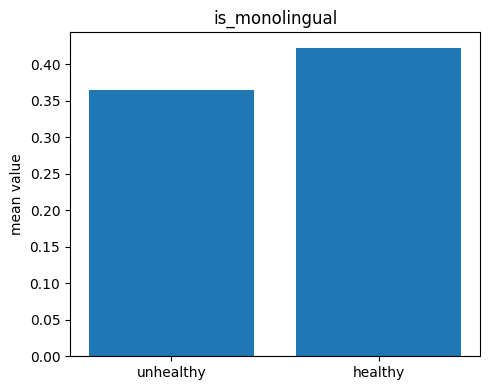

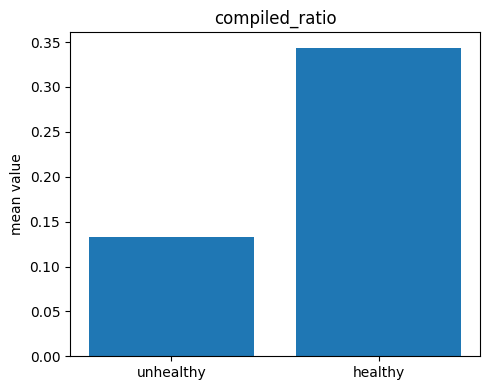

In [35]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


## **6. Repository Maintenance / Freshness**

**의미**

“현재도 유지되고 있는가”

**핵심 질문**
- maintenance dead 상태인가?
- update/push activity 유지되는가?

| 컬럼명                        | 의미                           | 해석                                            |
| -------------------------- | ---------------------------- | --------------------------------------------- |
| `repo_age_days`            | repository 생성 이후 경과 일수       | 프로젝트의 전체 운영 기간 및 역사성을 의미                      |
| `last_update_recency_days` | 마지막 update 이후 경과 일수          | 최근까지 metadata·issue·release 등 관리 활동이 있었는지 나타냄 |
| `last_push_recency_days`   | 마지막 push 이후 경과 일수            | 최근 코드 개발 및 유지보수 활동 여부를 의미                     |
| `update_push_gap_days`     | 마지막 update와 마지막 push 간 시간 차이 | 관리 활동과 실제 코드 개발 활동 간의 차이를 나타냄                 |


In [36]:
maintenance_features = [
    "repo_age_days",
    "last_update_recency_days",
    "last_push_recency_days",
    "update_push_gap_days",
]

In [37]:
maintain_df = df[maintenance_features + ["label"]].copy()

for col in maintenance_features:
    maintain_df[col] = pd.to_numeric(
        maintain_df[col],
        errors="coerce"
    )

summary_mean = (
    maintain_df
    .groupby("label")[maintenance_features]
    .mean()
    .T
)

summary_median = (
    maintain_df
    .groupby("label")[maintenance_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
repo_age_days,4416.826072,3642.866081,4592.701821,3581.404672,-773.959991,-1011.297149
last_update_recency_days,12.825472,0.333516,0.557576,0.066999,-12.491956,-0.490577
last_push_recency_days,614.058812,76.120469,113.886414,0.381254,-537.938343,-113.505160
update_push_gap_days,601.768226,75.810741,111.692384,0.295712,-525.957484,-111.396672


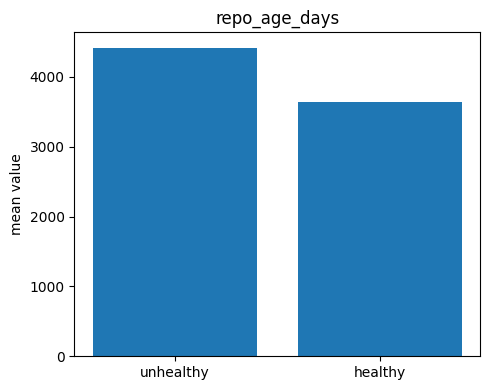

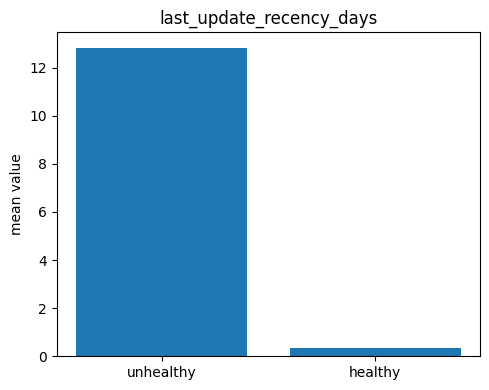

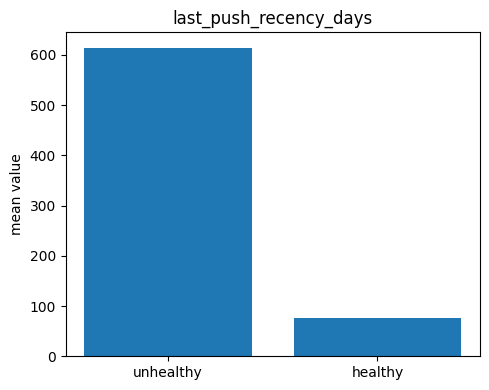

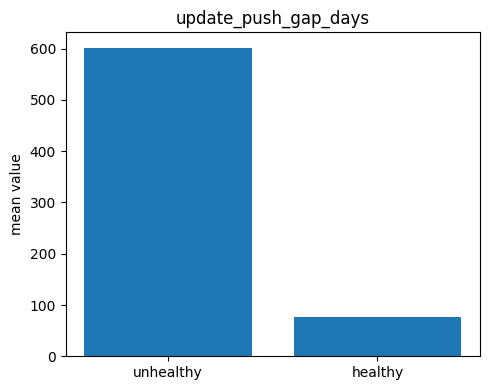

In [38]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


## **7. Repository Metadata / Governance**

**의미**

“프로젝트 운영 정책·상태”

**핵심 질문**
- archived 상태인가?
- wiki/discussion 사용하는가?
- governance openness 존재하는가?

| 컬럼명                 | 의미                             | 해석                               |
| ------------------- | ------------------------------ | -------------------------------- |
| `repo_size`         | repository 전체 크기               | 프로젝트 코드베이스 규모를 의미                |
| `open_issues_count` | 현재 open 상태인 issue 수            | 미해결 작업·버그·요청 규모를 나타냄             |
| `has_issues`        | GitHub issue 기능 활성화 여부         | issue 기반 관리 체계 사용 여부를 의미         |
| `has_projects`      | GitHub Projects 기능 활성화 여부      | 프로젝트 관리·task tracking 사용 여부를 나타냄 |
| `has_downloads`     | 다운로드 기능 활성화 여부                 | 배포·배포물 관리 기능 사용 여부를 의미           |
| `has_wiki`          | Wiki 기능 활성화 여부                 | 공식 문서·설명 체계 운영 여부를 나타냄           |
| `has_pages`         | GitHub Pages 활성화 여부            | 공식 웹페이지·문서 사이트 운영 여부를 의미         |
| `has_discussions`   | Discussions 기능 활성화 여부          | 커뮤니티 기반 소통 구조 존재 여부를 나타냄         |
| `archived`          | repository archive 여부          | 더 이상 적극적으로 유지보수되지 않는 상태 여부를 의미   |
| `disabled`          | repository 비활성화 여부             | repository 운영 중단 또는 접근 제한 상태를 의미 |
| `allow_forking`     | fork 허용 여부                     | 외부 협업 및 파생 개발 허용 여부를 나타냄         |
| `has_pull_requests` | Pull Request 기능 사용 여부          | 협업 기반 코드 리뷰·기여 구조 존재 여부를 의미      |
| `issues_per_size`   | repository 크기 대비 open issue 비율 | 코드 규모 대비 유지보수 부담 정도를 나타냄         |


In [39]:
governance_features = [
    "repo_size",
    "open_issues_count",
    "has_issues",
    "has_projects",
    "has_downloads",
    "has_wiki",
    "has_pages",
    "has_discussions",
    "archived",
    "disabled",
    "allow_forking",
    "has_pull_requests",
    "issues_per_size",
]

In [40]:
govern_df = df[governance_features + ["label"]].copy()

for col in governance_features:
    govern_df[col] = pd.to_numeric(
        govern_df[col],
        errors="coerce"
    )

summary_mean = (
    govern_df
    .groupby("label")[governance_features]
    .mean()
    .T
)

summary_median = (
    govern_df
    .groupby("label")[governance_features]
    .median()
    .T
)

summary = pd.concat(
    [
        summary_mean.rename(
            columns={
                0: "unhealthy_mean",
                1: "healthy_mean"
            }
        ),
        summary_median.rename(
            columns={
                0: "unhealthy_median",
                1: "healthy_median"
            }
        ),
    ],
    axis=1
)

summary["mean_diff_healthy_minus_unhealthy"] = (
    summary["healthy_mean"]
    - summary["unhealthy_mean"]
)

summary["median_diff_healthy_minus_unhealthy"] = (
    summary["healthy_median"]
    - summary["unhealthy_median"]
)

summary

label,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy
repo_size,116532.554745,337509.900735,17080.000000,113110.000000,220977.345991,96030.000000
open_issues_count,409.226277,1247.386029,99.000000,416.000000,838.159752,317.000000
has_issues,0.897810,0.952206,1.000000,1.000000,0.054396,0.000000
has_projects,0.656934,0.628676,1.000000,1.000000,-0.028258,0.000000
has_downloads,0.970803,0.977941,1.000000,1.000000,0.007138,0.000000
has_wiki,0.445255,0.386029,0.000000,0.000000,-0.059226,0.000000
has_pages,0.328467,0.231618,0.000000,0.000000,-0.096850,0.000000
has_discussions,0.255474,0.617647,0.000000,1.000000,0.362173,1.000000
archived,0.189781,0.036765,0.000000,0.000000,-0.153016,0.000000
disabled,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


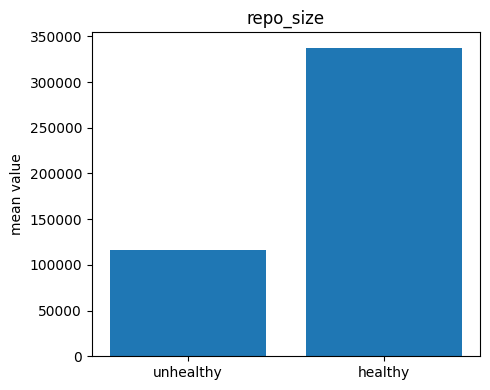

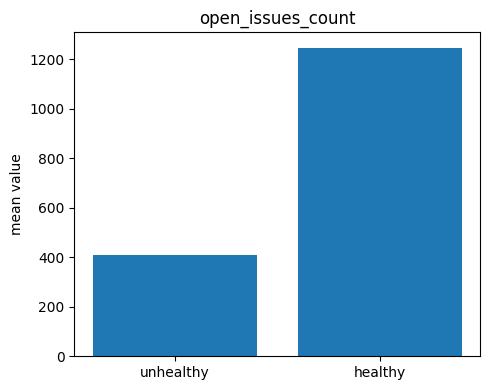

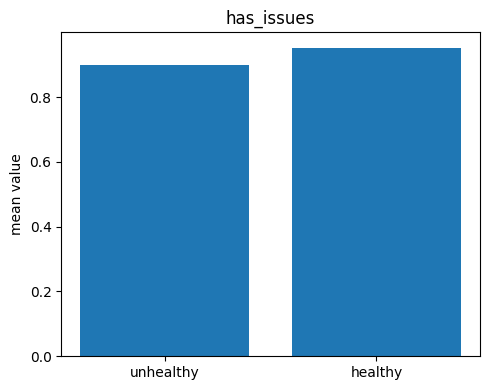

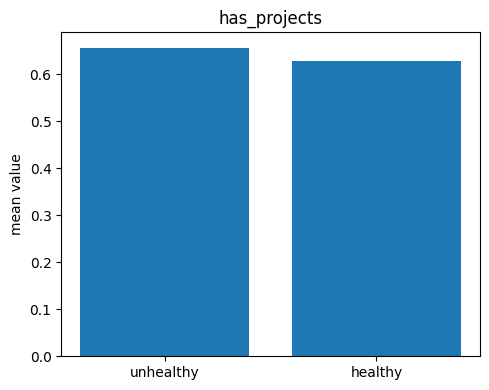

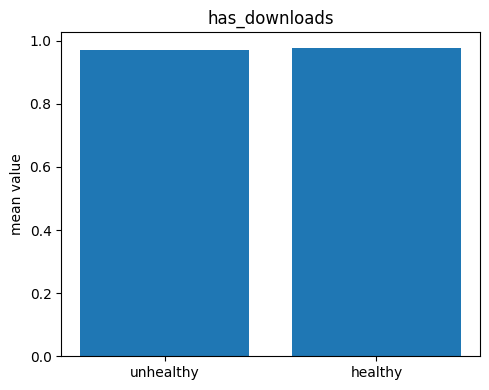

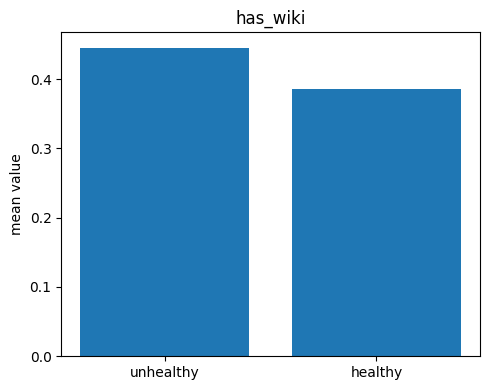

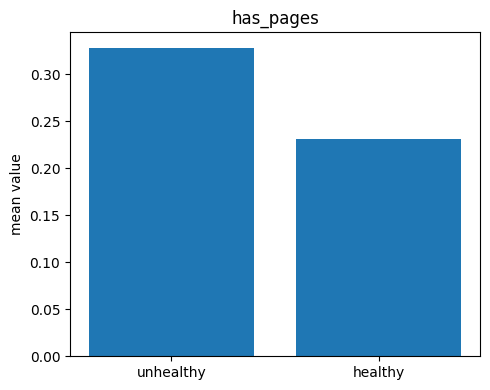

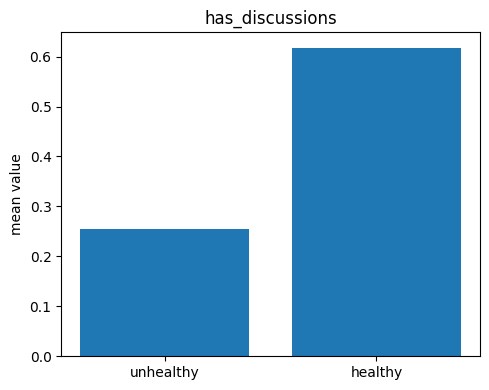

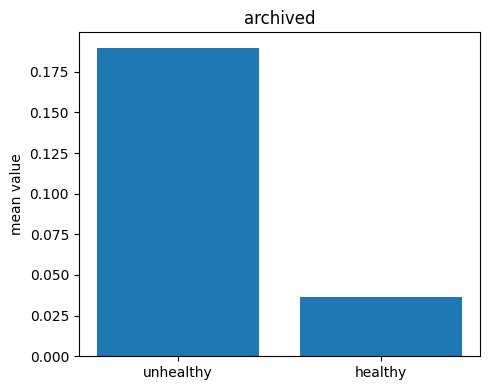

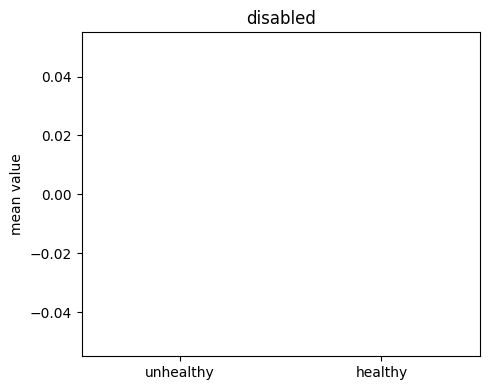

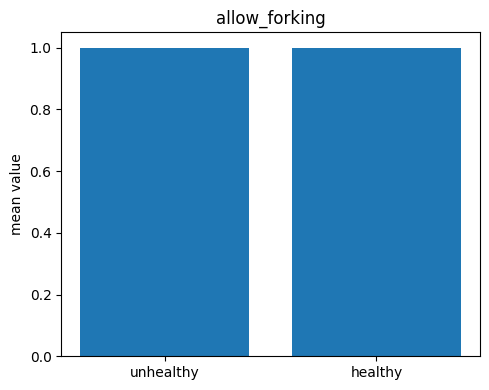

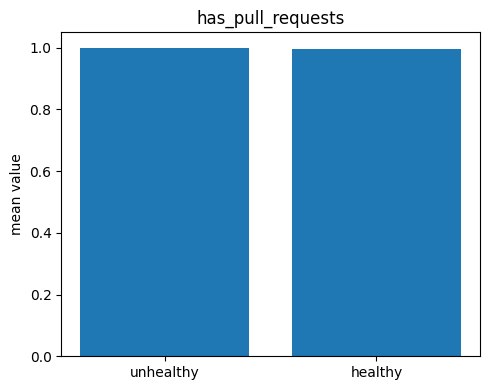

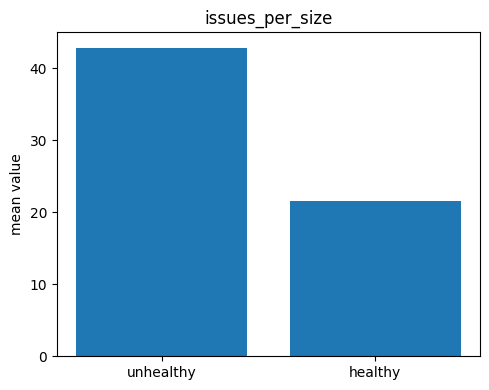

In [41]:
plot_df = summary[
    ["unhealthy_mean", "healthy_mean"]
].copy()

for feature in plot_df.index:

    plt.figure(figsize=(5, 4))

    values = plot_df.loc[feature]

    plt.bar(
        ["unhealthy", "healthy"],
        values
    )

    plt.title(feature)
    plt.ylabel("mean value")

    plt.tight_layout()
    plt.show()


---

# **OSS Health Feature Family 분석 정리**

## 1. 분석 목적

본 분석의 목적은 GitHub Open Source Repository의 운영적 건강성을 설명할 수 있는 feature들을 family 단위로 구분하고, 각 family가 healthy / unhealthy repository 구분에 어떤 의미를 가지는지 해석하는 것이다.

Feature family는 다음과 같이 구성하였다.

- Contributor
- Release / Deployment
- Event / Activity
- Popularity
- Language / Architecture
- Maintenance / Freshness
- Governance / Repository Metadata

이후 각 family별 feature를 기반으로 평균, 중앙값, 분포, 상관관계 등을 비교하여 OSS health와 관련 있는 주요 신호를 확인하였다.

---

## 2. Contributor Feature 분석

Contributor feature는 repository가 소수 maintainer에게 의존하는지, contribution이 얼마나 분산되어 있는지, contributor 생태계가 지속 가능한지를 보기 위한 지표이다.

주요 feature는 다음과 같다.

- `num_contributors`
- `total_contributions`
- `top1_contribution_share`
- `top5_contribution_share`
- `contribution_gini`
- `median_contributions`
- `top1_contribution_ratio`
- `top3_contribution_ratio`
- `contribution_entropy`
- `contributors_to_stars_ratio`

분석 결과 healthy repository는 단순히 contributor 수가 많거나 contribution 총량이 큰 것뿐 아니라, contribution이 더 넓게 분산되는 경향을 보였다.

특히 `total_contributions`, `median_contributions`, `contribution_entropy`는 healthy repository에서 더 높게 나타나는 경향이 있으며, 이는 단발성 참여보다 지속적인 기여 구조가 건강성과 관련됨을 의미한다.

반대로 `top1_contribution_share`, `top3_contribution_ratio`, `top5_contribution_share`, `contribution_gini`가 높은 repository는 소수 contributor 의존도가 높을 가능성이 있다. 이는 bus factor risk와 연결될 수 있으며, 장기적인 유지보수 안정성 측면에서는 부정적인 신호로 해석할 수 있다.

---

## 3. Release / Deployment Feature 분석

Release / Deployment feature는 repository가 실제로 운영되고 배포되는 프로젝트인지, release 관리 체계가 존재하는지를 확인하기 위한 지표이다.

주요 feature는 다음과 같다.

- `num_deployments`
- `has_deployments`
- `num_unique_refs`
- `tag_based_deployment_ratio`
- `deployment_recency_days`
- `num_tags`
- `stable_tag_ratio`
- `prerelease_tag_ratio`
- `latest_tag_is_stable`
- `latest_tag_is_prerelease`
- `semver_tag_ratio`
- `num_major_versions`
- `num_minor_versions`
- `tag_release_velocity`

분석 결과 healthy repository는 release 및 deployment 관련 활동이 더 활발한 경향을 보였다.

특히 `num_tags`, `semver_tag_ratio`, `stable_tag_ratio`, `latest_tag_is_stable`, `tag_release_velocity`는 release maturity를 설명하는 데 의미 있는 feature로 볼 수 있다.

`deployment_recency_days`는 값이 작을수록 최근 배포가 있었음을 의미하므로 healthy signal로 해석된다. 반대로 이 값이 클수록 release activity가 오래 정체되었을 가능성이 있다.

`prerelease_tag_ratio`, `latest_tag_is_prerelease`는 상황에 따라 해석이 필요하다. 실험적 개발이 활발한 프로젝트에서는 긍정적일 수 있으나, 안정적인 운영 상태를 평가하는 health score 관점에서는 stable release와 구분하여 다루는 것이 적절하다.

---

## 4. Event / Activity Feature 분석

Event feature는 repository가 실제로 살아 움직이는지, issue, pull request, comment, push 등 개발 및 상호작용 이벤트가 존재하는지를 나타낸다.

주요 feature는 다음과 같다.

- `num_events`
- `num_unique_event_types`
- `dominant_event_ratio`
- `event_type_entropy`
- `has_IssuesEvent`
- `has_PullRequestEvent`
- `has_IssueCommentEvent`
- `recent_event_density`
- `IssuesEvent_ratio`
- `IssueCommentEvent_ratio`
- `PullRequestEvent_ratio`
- `PushEvent_ratio`
- `WatchEvent_ratio`
- `ForkEvent_ratio`
- `interaction_ratio`
- `development_ratio`
- `external_interest_event_ratio`

분석 결과 Event family는 healthy / unhealthy repository를 구분하는 데 가장 강한 신호를 제공하는 family 중 하나로 나타났다.

Healthy repository는 `num_events`, `num_unique_event_types`, `event_type_entropy`가 높게 나타나는 경향이 있다. 이는 단순히 이벤트 수가 많은 것뿐 아니라, 다양한 유형의 활동이 발생하고 있음을 의미한다.

또한 `has_IssueCommentEvent`, `has_PullRequestEvent`, `interaction_ratio`, `development_ratio`가 healthy repository에서 더 높게 나타났다. 이는 healthy repository가 단순히 star나 fork를 받는 프로젝트가 아니라, 실제 개발과 협업이 일어나는 프로젝트일 가능성이 높다는 점을 보여준다.

반대로 `dominant_event_ratio`가 높으면 특정 이벤트 유형에 활동이 과도하게 집중되어 있음을 의미하므로, 활동 다양성 측면에서는 부정적인 신호가 될 수 있다.

---

## 5. Popularity / Ecosystem Interest Feature 분석

Popularity feature는 repository가 외부 생태계로부터 얼마나 관심을 받고 있는지를 나타낸다.

주요 feature는 다음과 같다.

- `stargazers_count`
- `subscribers_count`
- `subscribers_to_stars_ratio`
- `forks_count`
- `network_count`
- `forks_to_stars_ratio`
- `open_issues_to_stars_ratio`
- `stars_per_repo_age_day`
- `forks_per_repo_age_day`
- `stars_per_size`
- `forks_per_size`

Popularity feature는 health와 관련은 있지만, health 자체와 동일한 개념으로 보기는 어렵다.

Star, fork, subscriber 수가 높은 repository는 외부 관심도가 높다는 의미를 가지지만, 실제 유지보수 상태나 개발 활동이 활발하다는 것을 직접적으로 보장하지는 않는다.

따라서 popularity feature는 단독으로 사용하기보다 age, size, issue burden 등과 결합하여 보정된 지표로 사용하는 것이 적절하다.

예를 들어 `stars_per_repo_age_day`, `forks_per_repo_age_day`, `stars_per_size`, `forks_per_size`는 단순 popularity보다 repository 규모나 나이를 고려한 상대적 관심도를 반영한다.

---

## 6. Language / Architectural Diversity Feature 분석

Language feature는 repository의 기술 구조, 언어 다양성, architecture complexity를 설명하기 위한 지표이다.

주요 feature는 다음과 같다.

- `primary_language_ratio`
- `top2_ratio`
- `top3_ratio`
- `language_entropy`
- `minor_lang_ratio`
- `infra_ratio`
- `markup_ratio`
- `is_monolingual`
- `compiled_ratio`

Language family는 contributor, event, maintenance family에 비해 직접적인 health signal은 약할 수 있다.

그러나 `language_entropy`, `compiled_ratio`, `infra_ratio`, `minor_lang_ratio` 등은 프로젝트 구조의 복잡성이나 성숙도를 설명하는 보조 feature로 활용할 수 있다.

`is_monolingual`이나 `primary_language_ratio`가 높다는 것은 단일 언어 중심의 repository임을 의미한다. 이는 단순한 프로젝트일 수도 있고, 구조적으로 정리된 프로젝트일 수도 있으므로 단독 해석에는 주의가 필요하다.

---

## 7. Maintenance / Freshness Feature 분석

Maintenance feature는 repository가 현재도 유지되고 있는지, 최근 update나 push가 있었는지를 나타낸다.

주요 feature는 다음과 같다.

- `repo_age_days`
- `last_update_recency_days`
- `last_push_recency_days`
- `update_push_gap_days`

분석 결과 Maintenance family는 매우 강한 health signal을 제공한다.

Healthy repository는 `last_update_recency_days`, `last_push_recency_days`, `update_push_gap_days`가 낮게 나타나는 경향이 있다. 이는 최근까지 update와 push가 이루어지고 있으며, repository가 방치되지 않았다는 것을 의미한다.

`repo_age_days`는 해석에 주의가 필요하다. 오래된 repository라고 해서 반드시 unhealthy한 것은 아니지만, 오래되었고 최근 활동이 없다면 maintenance risk가 높다고 볼 수 있다.

따라서 maintenance feature는 단독 값보다 recency와 함께 해석하는 것이 적절하다.

---

## 8. Governance / Repository Metadata Feature 분석

Governance feature는 repository의 운영 정책, 기능 활성화 여부, archive 상태 등을 나타낸다.

주요 feature는 다음과 같다.

- `repo_size`
- `open_issues_count`
- `has_issues`
- `has_projects`
- `has_downloads`
- `has_wiki`
- `has_pages`
- `has_discussions`
- `archived`
- `disabled`
- `allow_forking`
- `has_pull_requests`
- `issues_per_size`

분석 결과 `has_discussions`, `has_issues`, `has_pull_requests` 등은 repository가 외부 참여와 협업을 허용하는 구조인지 판단하는 데 의미가 있다.

특히 `has_discussions`는 healthy repository에서 더 높게 나타나는 경향이 있으며, 이는 community interaction과 governance openness를 반영할 수 있다.

반대로 `archived`, `disabled`는 명확한 unhealthy signal로 볼 수 있다. 이러한 feature는 모델 해석에서도 방향성이 명확하므로 최종 feature set에 포함할 가치가 있다.

---

## 9. Feature Engineering 방향

기존 feature를 기반으로 다음과 같은 파생 feature를 추가할 수 있다.

### Contributor 기반 파생 feature

- `bus_factor_risk`
  - `top1_contribution_share`, `contribution_gini`를 결합하여 소수 contributor 의존도를 표현한다.

- `distributed_contribution_score`
  - `contribution_entropy`와 `1 - top1_contribution_share`를 결합하여 contribution 분산 정도를 표현한다.

### Release 기반 파생 feature

- `release_maturity_score`
  - `stable_tag_ratio`, `semver_tag_ratio`, `latest_tag_is_stable`을 결합하여 안정적인 release 체계를 표현한다.

- `active_release_score`
  - `num_tags`, `tag_release_velocity`를 결합하여 release activity의 양과 속도를 함께 반영한다.

### Event 기반 파생 feature

- `collaboration_event_score`
  - `PullRequestEvent_ratio`, `IssueCommentEvent_ratio`, `IssuesEvent_ratio`를 결합하여 협업 중심 활동을 표현한다.

- `activity_diversity_score`
  - `event_type_entropy`, `num_unique_event_types`를 결합하여 활동 다양성을 표현한다.

### Maintenance 기반 파생 feature

- `is_recently_pushed_30d`
  - 최근 30일 내 push 여부를 binary feature로 표현한다.

- `is_recently_updated_90d`
  - 최근 90일 내 update 여부를 binary feature로 표현한다.

- `push_update_consistency`
  - `update_push_gap_days`를 변환하여 update와 push 간의 일관성을 표현한다.

### Popularity 기반 파생 feature

- `adoption_efficiency`
  - star 수를 repository age로 보정하여 상대적 adoption 속도를 표현한다.

- `issue_burden_score`
  - open issue 수를 star 수로 보정하여 issue 부담 정도를 표현한다.

### Governance 기반 파생 feature

- `governance_openness_score`
  - issue, project, wiki, discussion, pull request 활성화 여부를 종합하여 repository openness를 표현한다.

---

## 10. 해석 모델 및 검증 방향

최종 dataset을 만들기 전에 다음 분석 절차를 수행하는 것이 적절하다.

1. Univariate analysis
   - healthy / unhealthy 간 평균 차이
   - 중앙값 차이
   - Mann-Whitney U test
   - effect size

2. Logistic Regression
   - StandardScaler 적용 후 coefficient 확인
   - coefficient를 odds ratio로 변환하여 feature 방향성 해석

3. Tree-based model
   - RandomForest, ExtraTrees, GradientBoosting 등을 사용하여 feature importance 확인

4. SHAP analysis
   - feature별 global importance 확인
   - healthy prediction과 unhealthy prediction에 기여하는 방향 확인

5. Attention 기반 분석
   - TabNet 또는 FT-Transformer와 같은 tabular attention model을 사용할 경우 보조적 해석 자료로 활용
   - 단, 현재 데이터 크기가 크지 않으므로 attention 결과는 주된 근거보다는 보조 근거로 사용하는 것이 적절함

6. Ablation test
   - family별 단독 성능 비교
   - 특정 family 제거 후 성능 변화 확인
   - 최종 feature set의 성능과 전체 feature set의 성능 비교

---

## 11. 최종 Feature Selection 기준

최종 dataset에 포함할 feature는 다음 기준을 종합하여 선택한다.

- healthy / unhealthy 간 분포 차이가 명확한 feature
- effect size가 큰 feature
- logistic regression에서 coefficient 방향성이 해석 가능한 feature
- odds ratio 해석이 domain knowledge와 일치하는 feature
- SHAP importance가 높은 feature
- family ablation에서 성능 기여가 확인되는 feature
- 중복성이 지나치게 높은 feature를 제거한 후에도 의미가 유지되는 feature
- 단순 popularity가 아닌 maintenance, collaboration, release maturity를 설명할 수 있는 feature

---

## 12. 최종 Dataset 구성 방향

최종 dataset은 기존 raw feature 전체를 그대로 사용하는 방식보다, 다음과 같이 구성하는 것이 적절하다.

- 원본 feature 중 해석 가능성과 예측 기여도가 높은 feature
- family별 대표 feature
- domain knowledge 기반 engineered feature
- label
- 필요 시 repository identifier

최종 feature set은 다음 family를 균형 있게 포함해야 한다.

- Activity
- Maintenance
- Release maturity
- Governance
- Contributor sustainability
- Popularity-adjusted adoption
- Language / architecture complexity

특히 OSS health를 설명하는 핵심 축은 단순 popularity가 아니라 다음 세 가지로 정리할 수 있다.

- 최근에도 유지보수되고 있는가
- 실제 개발 및 협업 이벤트가 발생하는가
- 안정적인 release / governance 구조를 가지고 있는가

따라서 최종 dataset은 star, fork 같은 popularity 지표에 과도하게 의존하지 않고, maintenance freshness, collaboration activity, release maturity, governance openness를 중심으로 구성하는 것이 적절하다.

---

In [42]:
df_train.columns

Index(['num_contributors', 'total_contributions', 'top1_contribution_share',
       'top5_contribution_share', 'contribution_gini', 'median_contributions',
       'num_deployments', 'has_deployments', 'num_unique_refs',
       'tag_based_deployment_ratio', 'deployment_recency_days', 'num_events',
       'num_unique_event_types', 'dominant_event_type', 'dominant_event_ratio',
       'event_type_entropy', 'has_IssuesEvent', 'has_PullRequestEvent',
       'has_IssueCommentEvent', 'recent_event_density', 'IssuesEvent_ratio',
       'IssueCommentEvent_ratio', 'PullRequestEvent_ratio', 'PushEvent_ratio',
       'WatchEvent_ratio', 'ForkEvent_ratio', 'stargazers_count',
       'subscribers_count', 'subscribers_to_stars_ratio',
       'primary_language_ratio', 'top2_ratio', 'top3_ratio',
       'language_entropy', 'minor_lang_ratio', 'infra_ratio', 'markup_ratio',
       'is_monolingual', 'compiled_ratio', 'num_tags', 'stable_tag_ratio',
       'prerelease_tag_ratio', 'latest_tag_is_stable',
 

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 81 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   num_contributors               409 non-null    float64
 1   total_contributions            409 non-null    float64
 2   top1_contribution_share        409 non-null    float64
 3   top5_contribution_share        409 non-null    float64
 4   contribution_gini              409 non-null    float64
 5   median_contributions           409 non-null    float64
 6   num_deployments                409 non-null    float64
 7   has_deployments                409 non-null    float64
 8   num_unique_refs                409 non-null    float64
 9   tag_based_deployment_ratio     409 non-null    float64
 10  deployment_recency_days        409 non-null    float64
 11  num_events                     409 non-null    float64
 12  num_unique_event_types         409 non-null    float64
 13  d

In [44]:
df["dominant_event_type"].unique()

<ArrowStringArray>
[                    'PushEvent',             'IssueCommentEvent',
              'PullRequestEvent',                    'WatchEvent',
                   'IssuesEvent',        'PullRequestReviewEvent',
 'PullRequestReviewCommentEvent',                   'DeleteEvent',
                     'ForkEvent',                             nan]
Length: 10, dtype: str

In [45]:
df["dominant_event_type"].dtype

<StringDtype(na_value=nan)>

In [46]:
from pandas import StringDtype
str_col = [i for i in df.columns if isinstance(df[i].dtype, StringDtype)]

In [47]:
str_col

['dominant_event_type', 'error']

In [48]:
cat_cols = df.select_dtypes(include=["string"]).columns
df = pd.get_dummies(df, columns=cat_cols)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 90 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   num_contributors                                                                             409 non-null    float64
 1   total_contributions                                                                          409 non-null    float64
 2   top1_contribution_share                                                                      409 non-null    float64
 3   top5_contribution_share                                                                      409 non-null    float64
 4   contribution_gini                                                                            409 non-null    float64
 5   median_contributions                           

In [50]:
df.columns

Index(['num_contributors', 'total_contributions', 'top1_contribution_share',
       'top5_contribution_share', 'contribution_gini', 'median_contributions',
       'num_deployments', 'has_deployments', 'num_unique_refs',
       'tag_based_deployment_ratio', 'deployment_recency_days', 'num_events',
       'num_unique_event_types', 'dominant_event_ratio', 'event_type_entropy',
       'has_IssuesEvent', 'has_PullRequestEvent', 'has_IssueCommentEvent',
       'recent_event_density', 'IssuesEvent_ratio', 'IssueCommentEvent_ratio',
       'PullRequestEvent_ratio', 'PushEvent_ratio', 'WatchEvent_ratio',
       'ForkEvent_ratio', 'stargazers_count', 'subscribers_count',
       'subscribers_to_stars_ratio', 'primary_language_ratio', 'top2_ratio',
       'top3_ratio', 'language_entropy', 'minor_lang_ratio', 'infra_ratio',
       'markup_ratio', 'is_monolingual', 'compiled_ratio', 'num_tags',
       'stable_tag_ratio', 'prerelease_tag_ratio', 'latest_tag_is_stable',
       'latest_tag_is_prereleas

In [51]:
df.drop(columns=['error_GitHub API request failed: 404 https://api.github.com/repos/coffeescript/coffeescript',
       'error_GitHub API request failed: 404 https://api.github.com/repos/torvalds/linux-stable'], inplace=True)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 88 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   num_contributors                                   409 non-null    float64
 1   total_contributions                                409 non-null    float64
 2   top1_contribution_share                            409 non-null    float64
 3   top5_contribution_share                            409 non-null    float64
 4   contribution_gini                                  409 non-null    float64
 5   median_contributions                               409 non-null    float64
 6   num_deployments                                    409 non-null    float64
 7   has_deployments                                    409 non-null    float64
 8   num_unique_refs                                    409 non-null    float64
 9   tag_based_deployment_

In [53]:
# df.to_parquet("addFeature.parquet")

In [56]:
eps = 1e-9

target_col = "label"

df_fe = df.copy()

df_fe["is_recently_pushed_30d"] = (
    df_fe["last_push_recency_days"] <= 30
).astype(int)

df_fe["is_recently_updated_90d"] = (
    df_fe["last_update_recency_days"] <= 90
).astype(int)

df_fe["push_update_consistency"] = (
    1 / (1 + df_fe["update_push_gap_days"])
)

df_fe["bus_factor_risk"] = (
    df_fe["top1_contribution_share"] + df_fe["contribution_gini"]
) / 2

df_fe["distributed_contribution_score"] = (
    df_fe["contribution_entropy"] * (1 - df_fe["top1_contribution_share"])
)

df_fe["release_maturity_score"] = (
    df_fe["stable_tag_ratio"]
    * df_fe["semver_tag_ratio"]
    * df_fe["latest_tag_is_stable"]
)

df_fe["active_release_score"] = (
    np.log1p(df_fe["num_tags"]) * df_fe["tag_release_velocity"]
)

df_fe["collaboration_event_score"] = (
    df_fe["PullRequestEvent_ratio"]
    + df_fe["IssueCommentEvent_ratio"]
    + df_fe["IssuesEvent_ratio"]
)

df_fe["activity_diversity_score"] = (
    df_fe["event_type_entropy"] * df_fe["num_unique_event_types"]
)

df_fe["adoption_efficiency"] = (
    np.log1p(df_fe["stargazers_count"])
    / np.log1p(df_fe["repo_age_days"] + 1)
)

df_fe["issue_burden_score"] = (
    df_fe["open_issues_count"]
    / (np.log1p(df_fe["stargazers_count"]) + eps)
)

df_fe["governance_openness_score"] = (
    df_fe["has_issues"]
    + df_fe["has_projects"]
    + df_fe["has_wiki"]
    + df_fe["has_discussions"]
    + df_fe["has_pull_requests"]
) / 5

df_fe["release_recency_score"] = (
    1 / (1 + df_fe["deployment_recency_days"])
)

df_fe["maintainer_activity_score"] = (
    df_fe["is_recently_pushed_30d"]
    + df_fe["is_recently_updated_90d"]
    + df_fe["push_update_consistency"]
) / 3

df_fe["healthy_activity_score"] = (
    df_fe["interaction_ratio"]
    + df_fe["development_ratio"]
    + df_fe["collaboration_event_score"]
) / 3

In [57]:
df_fe

,num_contributors,total_contributions,top1_contribution_share,top5_contribution_share,contribution_gini,median_contributions,num_deployments,has_deployments,num_unique_refs,tag_based_deployment_ratio,...,release_maturity_score,active_release_score,collaboration_event_score,activity_diversity_score,adoption_efficiency,issue_burden_score,governance_openness_score,release_recency_score,maintainer_activity_score,healthy_activity_score
0,30.0,3139.0,0.173941,0.475948,0.475385,61.5,30.0,1.0,2.0,0.0,...,1.00,0.038104,0.200000,14.514276,1.120369,39.076708,0.6,0.039538,0.929606,0.255556
1,19.0,9800.0,0.802143,0.997551,0.923963,2.0,0.0,0.0,0.0,0.0,...,0.00,0.025826,0.533333,7.465195,1.292549,5.131772,0.8,1.000000,0.929568,0.366667
2,30.0,3551.0,0.443537,0.813292,0.779283,21.5,30.0,1.0,1.0,0.0,...,1.00,0.076736,0.466667,11.455025,1.520583,29.669637,1.0,0.559197,0.994036,0.388889
3,30.0,1396.0,0.474928,0.803009,0.767240,8.5,30.0,1.0,30.0,0.0,...,1.00,0.056154,0.500000,13.088520,1.267934,8.604971,0.6,0.005604,0.875161,0.400000
4,30.0,17783.0,0.096947,0.307372,0.252978,506.5,0.0,0.0,0.0,0.0,...,0.00,0.042326,0.933333,6.128259,1.372017,82.623764,1.0,1.000000,0.999403,0.633333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,30.0,473.0,0.689218,0.773784,0.715927,4.0,30.0,1.0,1.0,0.0,...,0.00,0.000000,0.033333,0.873420,1.358130,2.181385,0.2,0.039376,0.679802,0.022222
407,30.0,4830.0,0.414079,0.908075,0.842636,18.5,30.0,1.0,8.0,0.0,...,0.00,0.017703,0.233333,3.889916,1.193524,45.327206,1.0,0.041042,0.958658,0.166667
408,3.0,3.0,0.333333,1.000000,0.000000,1.0,0.0,0.0,0.0,0.0,...,0.00,0.000000,0.166667,4.206237,0.948219,716.572953,0.8,1.000000,0.333859,0.111111
409,30.0,166.0,0.421687,0.819277,0.744980,1.0,0.0,0.0,0.0,0.0,...,0.00,0.000000,0.142857,5.718411,1.037310,13.952081,0.8,1.000000,0.334139,0.095238


In [58]:
keep_raw_features = [
    "last_push_recency_days",
    "last_update_recency_days",
    "update_push_gap_days",
    "repo_age_days",

    "event_type_entropy",
    "num_unique_event_types",
    "num_events",
    "has_IssueCommentEvent",
    "has_PullRequestEvent",
    "interaction_ratio",
    "development_ratio",
    "IssueCommentEvent_ratio",
    "PullRequestEvent_ratio",
    "external_interest_event_ratio",

    "num_tags",
    "tag_release_velocity",
    "semver_tag_ratio",
    "stable_tag_ratio",
    "latest_tag_is_stable",
    "deployment_recency_days",

    "has_discussions",
    "archived",
    "disabled",
    "has_issues",
    "has_pull_requests",

    "total_contributions",
    "median_contributions",
    "contribution_entropy",
    "top1_contribution_share",
    "contribution_gini",
    "top5_contribution_share",

    "subscribers_to_stars_ratio",
    "forks_to_stars_ratio",
    "open_issues_to_stars_ratio",

    "compiled_ratio",
    "language_entropy",
]

new_features = [
    "is_recently_pushed_30d",
    "is_recently_updated_90d",
    "push_update_consistency",
    "bus_factor_risk",
    "distributed_contribution_score",
    "release_maturity_score",
    "active_release_score",
    "collaboration_event_score",
    "activity_diversity_score",
    "adoption_efficiency",
    "issue_burden_score",
    "governance_openness_score",
    "release_recency_score",
    "maintainer_activity_score",
    "healthy_activity_score",
]

drop_features = [
    "Unnamed: 0",
    "repo_name",
    "dominant_event_type",
    "error",

    "oss_health_score",
    "community_activity_score",
    "contributor_sustainability_score",
    "release_engineering_score",
    "popularity_adoption_score",
    "language_structure_score",
    "maintenance_score",
    "governance_score",

    "top2_ratio",
    "top3_ratio",
    "primary_language_ratio",
    "minor_lang_ratio",
    "markup_ratio",
    "is_monolingual",

    "has_downloads",
    "has_pages",
    "has_projects",
    "has_wiki",
    "allow_forking",

    "num_deployments",
    "has_deployments",
    "num_unique_refs",
    "tag_based_deployment_ratio",
    "latest_tag_is_prerelease",
    "prerelease_tag_ratio",

    "stargazers_count",
    "forks_count",
    "network_count",
    "subscribers_count",
    "repo_size",
    "open_issues_count",

    "top1_contribution_ratio",
    "top3_contribution_ratio",
    "contributors_to_stars_ratio",

    "dominant_event_ratio",
    "WatchEvent_ratio",
    "ForkEvent_ratio",
    "PushEvent_ratio",
    "recent_event_density",
]

final_features = [
    col for col in keep_raw_features + new_features
    if col in df_fe.columns
]

if target_col == "label":
    exclude_targets = ["label", "new_label"]
else:
    exclude_targets = ["label", "new_label"]

final_dataset = df_fe[final_features + [target_col]].copy()

for col in final_features:
    final_dataset[col] = pd.to_numeric(final_dataset[col], errors="coerce")

print("Final dataset shape:", final_dataset.shape)
print("Target:", target_col)
print("Target distribution:")
print(final_dataset[target_col].value_counts())
print()
print("Number of final features:", len(final_features))

Final dataset shape: (411, 52)
Target: label
Target distribution:
label
1    274
0    137
Name: count, dtype: int64

Number of final features: 51


In [59]:
feature_family_map = {
    "maintenance": [
        "last_push_recency_days",
        "last_update_recency_days",
        "update_push_gap_days",
        "repo_age_days",
        "is_recently_pushed_30d",
        "is_recently_updated_90d",
        "push_update_consistency",
        "maintainer_activity_score",
    ],
    "event": [
        "event_type_entropy",
        "num_unique_event_types",
        "num_events",
        "has_IssueCommentEvent",
        "has_PullRequestEvent",
        "interaction_ratio",
        "development_ratio",
        "IssueCommentEvent_ratio",
        "PullRequestEvent_ratio",
        "external_interest_event_ratio",
        "collaboration_event_score",
        "activity_diversity_score",
        "healthy_activity_score",
    ],
    "release": [
        "num_tags",
        "tag_release_velocity",
        "semver_tag_ratio",
        "stable_tag_ratio",
        "latest_tag_is_stable",
        "deployment_recency_days",
        "release_maturity_score",
        "active_release_score",
        "release_recency_score",
    ],
    "governance": [
        "has_discussions",
        "archived",
        "disabled",
        "has_issues",
        "has_pull_requests",
        "governance_openness_score",
    ],
    "contributor": [
        "total_contributions",
        "median_contributions",
        "contribution_entropy",
        "top1_contribution_share",
        "contribution_gini",
        "top5_contribution_share",
        "bus_factor_risk",
        "distributed_contribution_score",
    ],
    "popularity_adjusted": [
        "subscribers_to_stars_ratio",
        "forks_to_stars_ratio",
        "open_issues_to_stars_ratio",
        "adoption_efficiency",
        "issue_burden_score",
    ],
    "language": [
        "compiled_ratio",
        "language_entropy",
    ],
}

feature_family = {}

for family, cols in feature_family_map.items():
    for col in cols:
        feature_family[col] = family

feature_selection_table = pd.DataFrame({
    "feature": final_features,
    "family": [feature_family.get(col, "other") for col in final_features],
    "source": [
        "engineered" if col in new_features else "raw"
        for col in final_features
    ],
})

feature_selection_table

,feature,family,source
0,last_push_recency_days,maintenance,raw
1,last_update_recency_days,maintenance,raw
2,update_push_gap_days,maintenance,raw
3,repo_age_days,maintenance,raw
4,event_type_entropy,event,raw
5,num_unique_event_types,event,raw
6,num_events,event,raw
7,has_IssueCommentEvent,event,raw
8,has_PullRequestEvent,event,raw
9,interaction_ratio,event,raw


In [60]:
discard_table = pd.DataFrame({
    "feature": [
        col for col in drop_features
        if col in df_fe.columns
    ]
})

discard_table

,feature
0,top2_ratio
1,top3_ratio
2,primary_language_ratio
3,minor_lang_ratio
4,markup_ratio
5,is_monolingual
6,has_downloads
7,has_pages
8,has_projects
9,has_wiki


In [61]:
from scipy.stats import mannwhitneyu

analysis_rows = []

for feature in final_features:
    unhealthy = final_dataset.loc[
        final_dataset[target_col] == 0, feature
    ].dropna()

    healthy = final_dataset.loc[
        final_dataset[target_col] == 1, feature
    ].dropna()

    unhealthy_mean = unhealthy.mean()
    healthy_mean = healthy.mean()

    unhealthy_median = unhealthy.median()
    healthy_median = healthy.median()

    pooled_std = np.sqrt(
        (unhealthy.var(ddof=1) + healthy.var(ddof=1)) / 2
    )

    cohen_d = (
        (healthy_mean - unhealthy_mean) / pooled_std
        if pooled_std > 0
        else np.nan
    )

    try:
        p_value = mannwhitneyu(
            unhealthy,
            healthy,
            alternative="two-sided"
        ).pvalue
    except:
        p_value = np.nan

    analysis_rows.append({
        "feature": feature,
        "family": feature_family.get(feature, "other"),
        "source": "engineered" if feature in new_features else "raw",
        "unhealthy_mean": unhealthy_mean,
        "healthy_mean": healthy_mean,
        "unhealthy_median": unhealthy_median,
        "healthy_median": healthy_median,
        "mean_diff_healthy_minus_unhealthy": healthy_mean - unhealthy_mean,
        "median_diff_healthy_minus_unhealthy": healthy_median - unhealthy_median,
        "cohen_d": cohen_d,
        "abs_cohen_d": abs(cohen_d),
        "p_value": p_value,
    })

univariate_result = pd.DataFrame(analysis_rows)

univariate_result.sort_values(
    ["abs_cohen_d", "p_value"],
    ascending=[False, True]
).head(30)

,feature,family,source,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy,cohen_d,abs_cohen_d,p_value
38,push_update_consistency,maintenance,engineered,0.163965,0.599290,0.008874,0.771777,0.435326,0.762903,1.256009,1.256009,5.968249e-25
49,maintainer_activity_score,maintenance,engineered,0.502343,0.808832,0.336291,0.923926,0.306489,0.587634,1.240071,1.240071,3.758936e-25
4,event_type_entropy,event,raw,0.645274,1.320618,0.540204,1.499143,0.675344,0.958939,1.216863,1.216863,2.286700e-23
5,num_unique_event_types,event,raw,3.007299,5.702206,3.000000,6.000000,2.694907,3.000000,1.187925,1.187925,1.255405e-22
44,activity_diversity_score,event,engineered,3.211243,8.611394,1.298497,9.013406,5.400151,7.714909,1.134674,1.134674,3.969572e-23
6,num_events,event,raw,18.781022,28.441176,28.000000,30.000000,9.660155,2.000000,1.011952,1.011952,9.864619e-19
36,is_recently_pushed_30d,maintenance,engineered,0.379562,0.821168,0.000000,1.000000,0.441606,1.000000,1.007016,1.007016,2.433433e-19
7,has_IssueCommentEvent,event,raw,0.335766,0.783088,0.000000,1.000000,0.447322,1.000000,1.006355,1.006355,8.864402e-19
42,active_release_score,release,engineered,0.012534,0.027591,0.016815,0.025785,0.015057,0.008970,0.974320,0.974320,1.133026e-19
15,tag_release_velocity,release,raw,0.003751,0.008091,0.005046,0.007512,0.004341,0.002466,0.960884,0.960884,1.270150e-19


In [62]:
univariate_result

,feature,family,source,unhealthy_mean,healthy_mean,unhealthy_median,healthy_median,mean_diff_healthy_minus_unhealthy,median_diff_healthy_minus_unhealthy,cohen_d,abs_cohen_d,p_value
0,last_push_recency_days,maintenance,raw,614.058812,76.120469,113.886414,0.381254,-537.938343,-113.505160,-0.807328,0.807328,2.341725e-25
1,last_update_recency_days,maintenance,raw,12.825472,0.333516,0.557576,0.066999,-12.491956,-0.490577,-0.397628,0.397628,1.623899e-11
2,update_push_gap_days,maintenance,raw,601.768226,75.810741,111.692384,0.295712,-525.957484,-111.396672,-0.797544,0.797544,5.968249e-25
3,repo_age_days,maintenance,raw,4416.826072,3642.866081,4592.701821,3581.404672,-773.959991,-1011.297149,-0.655578,0.655578,1.238092e-09
4,event_type_entropy,event,raw,0.645274,1.320618,0.540204,1.499143,0.675344,0.958939,1.216863,1.216863,2.286700e-23
5,num_unique_event_types,event,raw,3.007299,5.702206,3.000000,6.000000,2.694907,3.000000,1.187925,1.187925,1.255405e-22
6,num_events,event,raw,18.781022,28.441176,28.000000,30.000000,9.660155,2.000000,1.011952,1.011952,9.864619e-19
7,has_IssueCommentEvent,event,raw,0.335766,0.783088,0.000000,1.000000,0.447322,1.000000,1.006355,1.006355,8.864402e-19
8,has_PullRequestEvent,event,raw,0.364964,0.779412,0.000000,1.000000,0.414448,1.000000,0.919824,0.919824,1.811543e-16
9,interaction_ratio,event,raw,0.059722,0.189783,0.000000,0.140394,0.130061,0.140394,0.888498,0.888498,1.257064e-18


# OSS Health Analysis

## Analysis Overview

Healthy Repository와 Unhealthy Repository를 비교하기 위해 각 Feature에 대한 평균, 중앙값, Cohen's d(Effect Size), 통계적 유의성(p-value)을 분석하였다.

본 분석에서는 단순한 p-value보다 실제 영향력을 나타내는 Cohen's d를 중심으로 해석하였다.

일반적으로 Cohen's d는 다음과 같이 해석한다.

| Cohen's d | Interpretation |
|-----------|---------------|
| 0.2 | Small Effect |
| 0.5 | Medium Effect |
| 0.8 | Large Effect |
| > 1.0 | Very Large Effect |

---

# Finding 1. 건강한 프로젝트는 활동량보다 활동 다양성이 높다

가장 큰 효과 크기를 보인 Feature들은 Event Diversity 관련 변수들이었다.

| Feature | Cohen's d |
|----------|----------|
| push_update_consistency | 1.256 |
| maintainer_activity_score | 1.240 |
| event_type_entropy | 1.217 |
| num_unique_event_types | 1.188 |
| activity_diversity_score | 1.135 |

Healthy Repository는 단순히 많은 이벤트가 발생하는 것이 아니라 다양한 종류의 활동이 함께 발생하는 특징을 보였다.

구체적으로 Healthy Repository는

- 다양한 Event Type 존재
- 높은 Event Entropy
- 높은 Collaboration Activity
- 다양한 형태의 개발 및 유지보수 활동

을 동시에 나타냈다.

반면 Unhealthy Repository는 특정 이벤트 유형에 활동이 집중되는 경향을 보였다.

따라서 Repository 건강성은 단순한 Activity Volume보다 Activity Diversity와 더 강하게 연결되어 있다고 해석할 수 있다.

---

# Finding 2. 최근 유지보수 여부와 유지보수 일관성이 가장 강력한 건강성 신호이다

Maintenance 관련 Feature들은 매우 큰 효과 크기를 나타냈다.

| Feature | Healthy | Unhealthy | Cohen's d |
|----------|----------|----------|----------|
| last_push_recency_days | 76.1 | 614.1 | -0.807 |
| update_push_gap_days | 75.8 | 601.8 | -0.798 |
| is_recently_pushed_30d | 0.821 | 0.380 | 1.007 |
| push_update_consistency | 0.599 | 0.164 | 1.256 |
| maintainer_activity_score | 0.809 | 0.502 | 1.240 |

Healthy Repository는 최근까지 지속적으로 Push와 Update가 이루어지고 있었다.

특히 Push-Update Consistency는 전체 Feature 중 가장 큰 효과 크기를 보였다.

이는 단순히 최근 활동 여부만 중요한 것이 아니라,

- 꾸준한 유지보수
- 지속적인 업데이트
- 일관된 관리 활동

이 Repository 건강성에 매우 중요한 요소임을 시사한다.

반면 Unhealthy Repository는 수백 일 이상 활동이 중단된 경우가 많았으며, 장기간 방치된 저장소가 건강성 저하와 밀접하게 연결되는 것으로 나타났다.

---

# Finding 3. 건강한 OSS는 개인 프로젝트보다 커뮤니티 프로젝트에 가깝다

협업과 커뮤니티 활동을 나타내는 Feature 역시 강한 효과 크기를 보였다.

| Feature | Cohen's d |
|----------|----------|
| has_IssueCommentEvent | 1.006 |
| has_PullRequestEvent | 0.920 |
| collaboration_event_score | 0.850 |
| has_discussions | 0.782 |

Healthy Repository에서는

- Pull Request 활동 증가
- Issue Comment 증가
- Discussion 기능 활용
- 협업 이벤트 증가

가 동시에 관찰되었다.

이는 건강한 OSS가 단순히 코드가 존재하는 프로젝트가 아니라 다양한 참여자들이 지속적으로 상호작용하는 커뮤니티 기반 프로젝트임을 의미한다.

---

# Finding 4. Contributor 분산도가 높은 프로젝트가 더 건강하다

Contributor 관련 Feature에서도 의미 있는 차이가 확인되었다.

| Feature | Healthy 방향 |
|----------|----------|
| total_contributions | 증가 |
| median_contributions | 증가 |
| contribution_entropy | 증가 |
| top1_contribution_share | 감소 |
| contribution_gini | 감소 |
| top5_contribution_share | 감소 |

Healthy Repository는 특정 개발자에게 과도하게 의존하지 않는 특징을 보였다.

특히

- Contribution Entropy 증가
- Gini 감소
- Top Contributor 비중 감소

가 동시에 나타났다.

이는 Healthy Repository가 다수의 Contributor가 균형 있게 참여하는 구조를 가지고 있음을 의미한다.

반대로 Unhealthy Repository는 소수의 핵심 개발자에게 Contribution이 집중되는 경향이 강했다.

따라서 Contributor 분산도는 Repository 건강성을 설명하는 중요한 지표로 해석할 수 있다.

---

# Finding 5. Release 관리 체계가 건강한 프로젝트의 특징이다

Release 관련 Feature 역시 강한 효과 크기를 나타냈다.

| Feature | Cohen's d |
|----------|----------|
| active_release_score | 0.974 |
| tag_release_velocity | 0.961 |
| num_tags | 0.625 |
| semver_tag_ratio | 0.405 |

Healthy Repository는

- 더 많은 Release Tag
- 더 빠른 Release 주기
- 높은 Semantic Versioning 사용률
- 활발한 배포 활동

을 보였다.

이는 Healthy Repository가 단순 개발 단계에 머무르지 않고 실제 운영과 배포가 지속적으로 이루어지는 프로젝트임을 시사한다.

즉 Release Management Maturity가 Repository 건강성과 밀접한 관련을 가진다고 해석할 수 있다.

---

# Finding 6. Governance와 개방성이 건강성 향상에 기여한다

Governance 관련 변수에서도 유의한 차이가 나타났다.

| Feature | Cohen's d |
|----------|----------|
| has_discussions | 0.782 |
| archived | -0.496 |
| governance_openness_score | 0.317 |

Healthy Repository는

- Discussion 활성화
- 공개적인 의사소통 구조
- Archive 상태가 아님

과 같은 특징을 보였다.

반면 Unhealthy Repository는 Archived Repository 비율이 상대적으로 높았다.

이는 프로젝트 운영 과정에서의 개방성과 커뮤니티 참여 구조가 건강성 유지에 긍정적인 영향을 미친다는 것을 보여준다.

---

# Overall Interpretation

분석 결과 Repository 건강성은 단순한 활동량(Activity Volume)보다 다음 요소들과 더 강하게 연결되어 있었다.

1. Activity Diversity
2. Maintenance Consistency
3. Collaboration Activity
4. Contributor Distribution
5. Release Management Maturity
6. Governance Openness

특히 Event Diversity, Push-Update Consistency, Maintainer Activity와 같은 Feature들은 Cohen's d가 1.0 이상으로 나타나 매우 강력한 설명력을 보였다.

이는 Healthy OSS가 단순히 많은 Commit을 생성하는 프로젝트가 아니라,

- 지속적으로 관리되고,
- 다양한 활동이 발생하며,
- 여러 참여자가 협업하고,
- 정기적으로 Release를 수행하며,
- 개방적인 Governance 구조를 갖춘 프로젝트

라는 점을 시사한다.

---

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = final_dataset[final_features]
y = final_dataset[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

linear_model.fit(X_train, y_train)
linear_coef = linear_model.named_steps["model"].coef_[0]

linear_result = pd.DataFrame({
    "feature": final_features,
    "family": [feature_family.get(col, "other") for col in final_features],
    "coef": linear_coef,
    "odds_ratio_per_1sd": np.exp(linear_coef),
    "abs_coef": np.abs(linear_coef),
})

linear_result.sort_values(
    "abs_coef",
    ascending=False
).head(30)

,feature,family,coef,odds_ratio_per_1sd,abs_coef
44,activity_diversity_score,event,0.906107,2.474669,0.906107
42,active_release_score,release,0.821192,2.273208,0.821192
15,tag_release_velocity,release,0.805465,2.237738,0.805465
5,num_unique_event_types,event,-0.767160,0.464330,0.767160
1,last_update_recency_days,maintenance,-0.751559,0.471631,0.751559
25,total_contributions,contributor,0.688943,1.991610,0.688943
31,subscribers_to_stars_ratio,popularity_adjusted,-0.676140,0.508576,0.676140
14,num_tags,release,-0.662144,0.515744,0.662144
33,open_issues_to_stars_ratio,popularity_adjusted,0.552355,1.737339,0.552355
34,compiled_ratio,language,0.436431,1.547175,0.436431


In [67]:
linear_result.sort_values(
    "abs_coef",
    ascending=False
).head(50)

,feature,family,coef,odds_ratio_per_1sd,abs_coef
44,activity_diversity_score,event,0.906107,2.474669,0.906107
42,active_release_score,release,0.821192,2.273208,0.821192
15,tag_release_velocity,release,0.805465,2.237738,0.805465
5,num_unique_event_types,event,-0.767160,0.464330,0.767160
1,last_update_recency_days,maintenance,-0.751559,0.471631,0.751559
25,total_contributions,contributor,0.688943,1.991610,0.688943
31,subscribers_to_stars_ratio,popularity_adjusted,-0.676140,0.508576,0.676140
14,num_tags,release,-0.662144,0.515744,0.662144
33,open_issues_to_stars_ratio,popularity_adjusted,0.552355,1.737339,0.552355
34,compiled_ratio,language,0.436431,1.547175,0.436431


In [65]:
nonlinear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=700,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ))
])

nonlinear_model.fit(X_train, y_train)
nonlinear_importance = nonlinear_model.named_steps["model"].feature_importances_
nonlinear_result = pd.DataFrame({
    "feature": final_features,
    "family": [feature_family.get(col, "other") for col in final_features],
    "importance": nonlinear_importance,
})
nonlinear_result.sort_values(
    "importance",
    ascending=False
).head(30)

,feature,family,importance
38,push_update_consistency,maintenance,0.082718
7,has_IssueCommentEvent,event,0.064086
49,maintainer_activity_score,maintenance,0.056881
36,is_recently_pushed_30d,maintenance,0.046673
6,num_events,event,0.041111
44,activity_diversity_score,event,0.039854
4,event_type_entropy,event,0.039396
14,num_tags,release,0.036260
42,active_release_score,release,0.034203
5,num_unique_event_types,event,0.033074


In [68]:
nonlinear_result.sort_values(
    "importance",
    ascending=False
).head(50)

,feature,family,importance
38,push_update_consistency,maintenance,0.082718
7,has_IssueCommentEvent,event,0.064086
49,maintainer_activity_score,maintenance,0.056881
36,is_recently_pushed_30d,maintenance,0.046673
6,num_events,event,0.041111
44,activity_diversity_score,event,0.039854
4,event_type_entropy,event,0.039396
14,num_tags,release,0.036260
42,active_release_score,release,0.034203
5,num_unique_event_types,event,0.033074


In [66]:
family_importance = (
    nonlinear_result
    .groupby("family")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
family_importance

,family,importance
0,event,0.382998
1,maintenance,0.266390
2,release,0.146432
3,popularity_adjusted,0.070906
4,contributor,0.068928
5,governance,0.036021
6,language,0.028325


# Feature Importance 분석

## 핵심 결과

Feature importance 분석 결과, Healthy OSS를 설명하는 가장 중요한 요인은 **Event Activity**, **Maintenance Activity**, 그리고 **Release Management**로 나타났다.

Family 단위 중요도를 살펴보면 Event Feature가 전체 중요도의 약 38.3%로 가장 높은 비중을 차지하였으며, Maintenance Feature(26.6%)와 Release Feature(14.6%)가 그 뒤를 이었다.

이는 Healthy OSS가 단순히 많은 사용자를 보유한 프로젝트가 아니라,

* 활발한 개발 활동(Event)
* 지속적인 유지보수(Maintenance)
* 체계적인 Release 관리(Release)

를 동시에 수행하는 프로젝트라는 점을 시사한다.

---

# Family Importance 분석

| Family              | Importance |
| ------------------- | ---------: |
| Event               |      0.383 |
| Maintenance         |      0.266 |
| Release             |      0.146 |
| Popularity Adjusted |      0.071 |
| Contributor         |      0.069 |
| Governance          |      0.036 |
| Language            |      0.028 |

### 해석

Event + Maintenance + Release 계열이 전체 중요도의 약 80% 이상을 차지하였다.

반면 Governance, Language, Popularity 관련 변수들은 보조적인 역할에 머물렀다.

이는 OSS Health를 결정하는 핵심 요소가 프로젝트의 구조적 속성보다도 실제 운영 과정에서 발생하는 활동 패턴이라는 점을 보여준다.

즉,

* 얼마나 다양한 활동이 발생하는가
* 얼마나 꾸준히 유지보수되는가
* 얼마나 체계적으로 release를 수행하는가

가 건강한 OSS를 구분하는 핵심 신호로 나타났다.

---

# Linear Model Feature Importance 분석

## 주요 Feature

| Feature                    | Family              | OR (1 SD 증가) | 해석                           |
| -------------------------- | ------------------- | -----------: | ---------------------------- |
| activity_diversity_score   | event               |        2.47x | 다양한 활동 유형 존재                 |
| active_release_score       | release             |        2.27x | 활발한 release lifecycle        |
| tag_release_velocity       | release             |        2.24x | 빠른 release/update cadence    |
| total_contributions        | contributor         |        1.99x | 전체 contributor activity 증가   |
| open_issues_to_stars_ratio | popularity_adjusted |        1.74x | 사용자 참여 및 issue reporting 활성화 |
| compiled_ratio             | language            |        1.55x | 상대적으로 엔지니어링 중심 프로젝트          |
| event_type_entropy         | event               |        1.33x | 균형 잡힌 이벤트 구조                 |
| IssueCommentEvent_ratio    | event               |        1.29x | 활발한 개발자 상호작용                 |
| interaction_ratio          | event               |        1.25x | 협업 활동 증가                     |

### 해석

가장 강력한 positive signal은 activity diversity와 release activity였다.

특히:

* `activity_diversity_score`
* `active_release_score`
* `tag_release_velocity`

가 상위권을 차지한 것은 Healthy OSS가 단순히 commit 수가 많은 프로젝트가 아니라 다양한 개발 활동과 지속적인 release cycle을 유지하는 프로젝트임을 의미한다.

또한:

* IssueComment
* Interaction
* Contribution

계열 feature가 중요하게 나타난 것은 Healthy OSS가 개발자 간 협업 구조를 적극적으로 유지하는 repository라는 점을 보여준다.

---

## 주요 Negative Coefficient Feature

| Feature                    |    OR | 해석 |
| -------------------------- | ----: | -- |
| num_unique_event_types     | 0.46x |    |
| last_update_recency_days   | 0.47x |    |
| subscribers_to_stars_ratio | 0.51x |    |
| num_tags                   | 0.52x |    |
| update_push_gap_days       | 0.77x |    |
| repo_age_days              | 0.77x |    |
| bus_factor_risk            | 0.77x |    |

### 해석 시 주의점

이러한 변수들은 개별적으로 healthy와 양의 관계를 가질 수 있음에도 불구하고 다중 변수 로지스틱 회귀에서는 음의 계수로 나타났다.

이는 다음과 같은 현상 때문일 가능성이 높다.

* feature 간 높은 상관관계(multicollinearity)
* composite score에 의한 정보 흡수
* release/activity 변수 간 중복 설명력

대표적으로:

* `num_unique_event_types`
* `num_tags`

는 단독 통계에서는 healthy repository가 더 높은 값을 보였지만,

이미 모델 내에

* activity_diversity_score
* active_release_score
* event_entropy

등이 포함되어 있기 때문에 조건부 효과(conditioned effect)가 음수로 뒤집힌 것으로 해석된다.

따라서 해당 계수 자체보다는 변수 중요도와 전체 모델 구조를 함께 해석하는 것이 적절하다.

---

# Nonlinear Model Feature Importance 분석

## Top Features

| Rank | Feature                   | Family      | Importance |
| ---- | ------------------------- | ----------- | ---------: |
| 1    | push_update_consistency   | maintenance |     0.0827 |
| 2    | has_IssueCommentEvent     | event       |     0.0641 |
| 3    | maintainer_activity_score | maintenance |     0.0569 |
| 4    | is_recently_pushed_30d    | maintenance |     0.0467 |
| 5    | num_events                | event       |     0.0411 |
| 6    | activity_diversity_score  | event       |     0.0399 |
| 7    | event_type_entropy        | event       |     0.0394 |
| 8    | num_tags                  | release     |     0.0363 |
| 9    | active_release_score      | release     |     0.0342 |
| 10   | num_unique_event_types    | event       |     0.0331 |

---

## 비선형 모델의 특징

비선형 모델에서는 release quantity보다 maintenance consistency가 더욱 중요하게 나타났다.

특히 상위 feature는 대부분:

* 최근 활동 여부
* 업데이트 지속성
* maintainer activity
* 이벤트 다양성

관련 변수였다.

이는 Healthy OSS를 판단할 때 단순히 release 수나 contributor 수보다도

"현재도 살아 움직이고 있는가?"

라는 operational signal이 더욱 중요하다는 점을 시사한다.

대표적으로:

* `push_update_consistency`
* `maintainer_activity_score`
* `is_recently_pushed_30d`

가 상위권에 위치한 것은 지속적인 유지보수 자체가 OSS 건강성의 핵심 요소임을 보여준다.

---

# Event Feature의 압도적 중요성

Event Family는

* Linear Model 최상위 feature 다수 포함
* Nonlinear Model 최상위 feature 다수 포함
* Family Importance 1위

를 동시에 기록하였다.

특히 중요한 변수는:

* activity_diversity_score
* num_events
* event_type_entropy
* has_IssueCommentEvent
* num_unique_event_types
* development_ratio
* interaction_ratio

등이었다.

이는 Healthy OSS가 단순히 코드 저장소(repository)가 아니라,

* 개발
* 리뷰
* 토론
* 기여
* 유지보수

가 지속적으로 순환하는 collaborative ecosystem임을 의미한다.

---

# Maintenance Feature의 중요성

Maintenance Family는 전체 중요도 2위를 차지하였다.

주요 변수:

* push_update_consistency
* maintainer_activity_score
* last_push_recency_days
* last_update_recency_days
* is_recently_pushed_30d

등이 상위권에 위치하였다.

이는 Healthy OSS가 "과거에 성공했던 프로젝트"가 아니라

현재 시점에서도 지속적으로 관리되고 있는 프로젝트라는 점을 보여준다.

---

# Release Feature의 중요성

Release Family 역시 강한 설명력을 보였다.

특히:

* active_release_score
* tag_release_velocity
* num_tags
* semver_tag_ratio

등이 중요한 변수로 나타났다.

이는 Healthy OSS가 체계적인 versioning 정책과 release lifecycle을 유지하는 프로젝트라는 점을 의미한다.

즉,

* 정기적 release
* semantic versioning
* 안정적인 버전 관리

가 OSS 건강성의 핵심 구성요소로 작용하고 있음을 확인할 수 있다.

---

# 해석 요약

Feature importance 분석 결과 Healthy OSS를 설명하는 가장 중요한 요소는 Event Activity, Maintenance Consistency, 그리고 Release Management였다.

특히 Healthy OSS는 단순히 인기 있는 프로젝트가 아니라:

* 다양한 개발 이벤트가 발생하고,
* 개발자 간 상호작용이 활발하며,
* 지속적으로 유지보수되고,
* 체계적인 release lifecycle을 운영하는

프로젝트라는 점이 확인되었다.

반면 popularity, language, governance와 같은 구조적 특성은 보조적인 설명력을 가졌으며, 실제 OSS 건강성은 운영 과정에서 발생하는 활동 패턴과 유지보수 지속성에 의해 더 강하게 결정되는 것으로 나타났다.


---